dR/dE_R spectra (paper)

In [1]:
import numpy as np

def choose_Kmax(mchi_MeV, delta_keV, Tsun_keV=1.10, tail_tol=1e-6, peak_factor=5.0):
    m_e_keV  = 511.0
    mchi_keV = np.asarray(mchi_MeV, dtype=float) * 1.0e3     # MeV -> keV
    mu       = (mchi_keV * m_e_keV) / (mchi_keV + m_e_keV)   # keV
    a        = m_e_keV / (2.0 * Tsun_keV)                    # ~232.3
    beta     = a * mchi_keV / (2.0 * mu * mu)                # 1/keV
    K_tail   = np.log(1.0 / tail_tol) / beta                 # keV
    K_peak   = delta_keV * mu / mchi_keV                     # keV

    Kmax = np.maximum(K_tail, peak_factor * K_peak)
    return Kmax if np.ndim(Kmax) else float(Kmax)

print(choose_Kmax(0.1, 0.1))
print(choose_Kmax(0.1, 10))
print(choose_Kmax(14, 0.5))
print(choose_Kmax(14, 10))

8.32066611268235
41.81669394435352
2.0652558792766973
2.0652558792766973


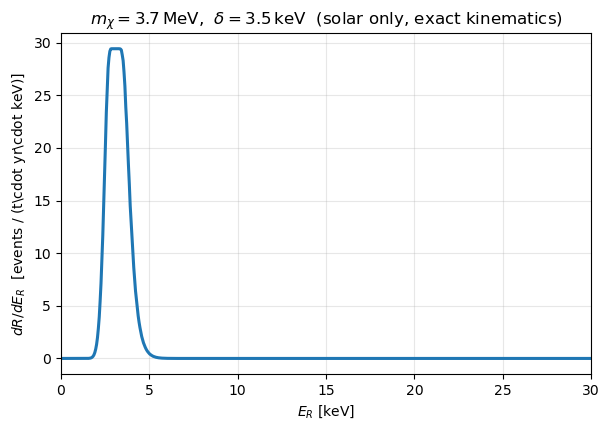

In [2]:
import numpy as np
import matplotlib.pyplot as plt

alpha_em     = 1/137.035999084

# ---------------- Astrophysics / geometry ----------------
AU_cm        = 1.495978707e13        # 1 AU [cm]
rho0_GeVcm3  = 0.30                  # local DM density ρ0 [GeV/cm^3]
vesc_over_v0 = 7.0                   # gravitational focusing ~ v_esc/v0
C_LIGHT_CM_S = 2.99792458e10         # speed of light [cm/s]

# ---------------- Solar "one-zone" inputs (Sec. 4) -------
T_sun_keV    = 1.10                  # core electron temperature [keV]
n_e_core     = 2.0e25                # core electron number density [cm^-3]
V_core_cm3   = 2.2e31                # effective core volume [cm^3]

# ---------------- Detector / Xenon -----------------------
A_Xe_gmol    = 131.293               # Xe molar mass [g/mol]
Zfree_Xe     = 26                    # effective "free" electrons per Xe atom
N_A          = 6.022_140_76e23       # Avogadro
SEC_PER_YR   = 365.25*24*3600.0      # [s/yr]

# ---------------- Particles / units ----------------------
m_e_keV      = 511.0                 # electron mass [keV]
GEV2_TO_CM2  = 0.389379e-27          # GeV^-2 → cm^2
KEV_PER_GEV  = 1.0e6                 # 1 GeV = 1e6 keV
_EPS         = 1e-300

# Targets per tonne (free-e approximation)
NT_per_g     = N_A * Zfree_Xe / A_Xe_gmol
NT_per_ton   = NT_per_g * 1.0e6

# ============================ Thermal target & σ_e (Eq. 2.3) ============================
def y_from_eps_line(mchi_GeV, *, alpha_D=0.5, r=3.0, eps0=1e-4, m0_GeV=0.1):
    mchi_GeV = np.asarray(mchi_GeV, float)
    eps = eps0 * (mchi_GeV / m0_GeV) * (r / 3.0)**2 * (alpha_D / 0.5)**(-0.5)
    return (eps**2) * alpha_D / (r**4)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r=3.0):
    mchi_GeV = np.asarray(mchi_GeV, float)
    me_GeV   = m_e_keV * 1e-6
    mu_GeV   = (mchi_GeV * me_GeV) / (mchi_GeV + me_GeV)

    y        = y_from_eps_line(mchi_GeV, alpha_D=alpha_D, r=r)
    sig_GeV2 = 16.0 * np.pi * alpha_em * (mu_GeV**2) * y / (mchi_GeV**4)
    return sig_GeV2 * GEV2_TO_CM2



# ================= Kinematics for solar production =================
def mu_keV(mchi_GeV):
    """Reduced mass μ_χe in keV."""
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * m_e_keV) / (mchi_keV + m_e_keV)

def vmin2_for_Kstar(mchi_GeV, Kstar_keV, delta_keV):
    """
    Exact Eq. (4.6):
      v_min^2 = [ (mχ K*/μ + δ)^2 ] / (2 mχ K*)
    (all energies in keV; returns dimensionless v_min^2)
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)      # avoid division by zero at K*=0
    term     = (mchi_keV * Ksafe) / mu + delta_keV
    return (term * term) / (2.0 * mchi_keV * Ksafe)

def I_MB(vmin2):
    """
    Correct MB average for Eq. (4.5) at fixed K*:
      I(v_min) = ∫_{vmin}^∞ f_MB(v)/v dv
               = sqrt(2 m_e / (π T)) * exp[- m_e v_min^2 / (2T)]
    """
    a    = m_e_keV / (2.0 * T_sun_keV)
    pref = np.sqrt(2.0 * m_e_keV / (np.pi * T_sun_keV))
    return pref * np.exp(-a * vmin2)

# ===================== Solar χ* flux dΦ/dK* (to Earth) =======================
def dphi_dKstar_solar(mchi_GeV, delta_keV, Kgrid_keV):
    """
    dΦ/dK* = [ n_e n_χ^core σ_e * (mχ / (2 μ^2)) * I_MB(v_min(K*)) * c ] × (V_core / 4π AU^2)
    Returns cm^-2 s^-1 keV^-1.
    """
    n_chi_inf  = rho0_GeVcm3 / (mchi_GeV + _EPS)        # [cm^-3]
    n_chi_core = n_chi_inf * vesc_over_v0               # [cm^-3]

    sig_e      = sigma_e_contact(mchi_GeV)              # [cm^2]
    mchi_keV   = mchi_GeV * KEV_PER_GEV
    mu         = mu_keV(mchi_GeV)

    # Multiply by c because v in the MB integral is dimensionless (natural units)
    pref_prod  = n_e_core * n_chi_core * sig_e * (mchi_keV / (2.0 * mu * mu)) * C_LIGHT_CM_S

    vmin2      = vmin2_for_Kstar(mchi_GeV, Kgrid_keV, delta_keV)
    prod_core  = pref_prod * I_MB(vmin2)                # [cm^-3 s^-1 keV^-1]

    geom       = V_core_cm3 / (4.0 * np.pi * AU_cm**2)  # [cm]
    return geom * prod_core                             # [cm^-2 s^-1 keV^-1]

# ===================== Detector-side (down-scatter) ==========================
def vchi2_from_K(mchi_GeV, K_keV):
    """χ* speed squared at detector: v^2 = 2K / mχ (mχ in keV)."""
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return 2.0 * K_keV / (mchi_keV + _EPS)

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    """
    Exact lower limit on K* for a given recoil ER (equivalent to the recoil-band condition):
        v_min(ER) = |(m_e/μ) ER - δ| / sqrt(2 m_e ER),
        K_min(ER) = 1/2 * mχ * v_min(ER)^2.
    All energies in keV; returns K_min in keV.
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)

    ER  = np.asarray(ER_keV, float)
    ERs = np.maximum(ER, 1e-12)  # avoid division by zero at ER→0

    vmin = np.abs((m_e_keV/mu) * ERs - delta_keV) / np.sqrt(2.0 * m_e_keV * ERs)
    Kmin = 0.5 * mchi_keV * vmin * vmin
    return Kmin

def detector_kernel_dsigmadER(mchi_GeV, K_keV):
    """
    dσ/dE_R ≈ σ_e * m_e / (2 μ^2 v^2), with v^2 = 2K/mχ.  Returns cm^2/keV.
    """
    mu = mu_keV(mchi_GeV)
    v2 = np.maximum(vchi2_from_K(mchi_GeV, K_keV), 1e-30)
    return sigma_e_contact(mchi_GeV) * (m_e_keV / (2.0 * mu * mu * v2))

# ============================= Spectrum dR/dE_R ==============================
def dRdER_solar_only(mchi_GeV, delta_keV, ER_grid_keV, Kmax_keV=60.0, NK=2000):
    """
    dR/dE_R = N_T ∫_{Kmin(E_R)}^∞ dK [ dΦ/dK ] [ dσ/dE_R ].
    Output: events / (tonne · yr · keV)
    """
    K_grid = np.linspace(0.0, Kmax_keV, NK)
    dphi   = dphi_dKstar_solar(mchi_GeV, delta_keV, K_grid)
    kernel = detector_kernel_dsigmadER(mchi_GeV, K_grid)

    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid >= Kmin
        if np.any(m):
            integ = np.trapz(dphi[m] * kernel[m], K_grid[m])   # per target [s^-1 keV^-1]
            out[i] = NT_per_ton * integ * SEC_PER_YR           # events / (t·yr·keV)
    return out

# ================================= Demo plot =================================
if __name__ == "__main__":
    mchi_MeV  = 3.7
    delta_keV = 3.5
    mchi_GeV  = mchi_MeV * 1e-3

    KMAX=40
    NK=4000

    ER   = np.linspace(0.01, 30.0, 600)
    spec = dRdER_solar_only(mchi_GeV, delta_keV, ER, Kmax_keV=KMAX, NK=NK)

    plt.figure(figsize=(6.2, 4.4))
    plt.plot(ER, spec, lw=2.2)
    plt.xlabel(r"$E_R$ [keV]")
    plt.ylabel(r"$dR/dE_R$  [events / (t\cdot yr\cdot keV)]")
    plt.title(rf"$m_\chi={mchi_MeV}\,$MeV,  $\delta={delta_keV}\,$keV  (solar only, exact kinematics)")
    plt.grid(alpha=0.3)
    plt.xlim(0, 30)
    plt.tight_layout()
    plt.show()

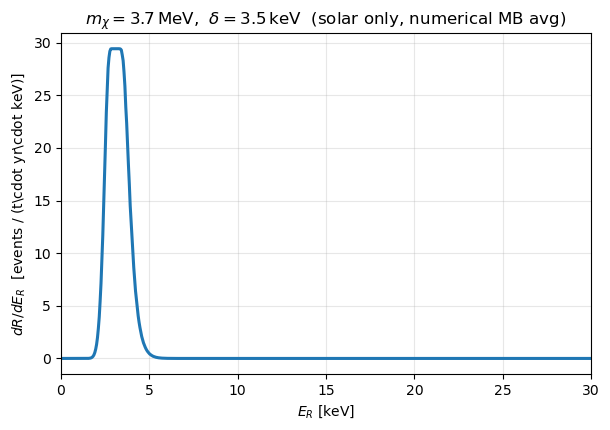

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================== Constants (paper) ==============================
alpha_em     = 1/137.035999084

# Astrophysics / geometry
AU_cm        = 1.495978707e13        # 1 AU [cm]
rho0_GeVcm3  = 0.30                  # local DM density ρ0 [GeV/cm^3]
vesc_over_v0 = 7.0                   # gravitational focusing ~ v_esc/v0
C_LIGHT_CM_S = 2.99792458e10         # speed of light [cm/s]  <-- normalization fix

# Solar "one-zone" inputs (Sec. 4)
T_sun_keV    = 1.10                  # core electron temperature [keV]
n_e_core     = 2.0e25                # core electron number density [cm^-3]
V_core_cm3   = 2.2e31                # effective core volume [cm^3]

# Detector / Xenon
A_Xe_gmol    = 131.293               # Xe molar mass [g/mol]
Zfree_Xe     = 26                    # effective "free" electrons per Xe atom
N_A          = 6.022_140_76e23       # Avogadro
SEC_PER_YR   = 365.25*24*3600.0      # [s/yr]

# Particles
m_e_keV      = 511.0                 # electron mass [keV]

# Unit helpers
GEV2_TO_CM2  = 0.389379e-27          # GeV^-2 → cm^2
KEV_PER_GEV  = 1.0e6                 # 1 GeV = 1e6 keV
_EPS         = 1e-300

# Targets per tonne (free-e approximation)
NT_per_g     = N_A * Zfree_Xe / A_Xe_gmol
NT_per_ton   = NT_per_g * 1.0e6

# ============================ Thermal target & σ_e (Eq. 2.3) ============================
def y_from_eps_line(mchi_GeV, *, alpha_D=0.5, r=3.0, eps0=1e-4, m0_GeV=0.1):
    mchi_GeV = np.asarray(mchi_GeV, float)
    eps = eps0 * (mchi_GeV / m0_GeV) * (r / 3.0)**2 * (alpha_D / 0.5)**(-0.5)
    return (eps**2) * alpha_D / (r**4)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r=3.0):

    mchi_GeV = np.asarray(mchi_GeV, float)
    me_GeV   = m_e_keV * 1e-6
    mu_GeV   = (mchi_GeV * me_GeV) / (mchi_GeV + me_GeV)

    y        = y_from_eps_line(mchi_GeV, alpha_D=alpha_D, r=r)
    sig_GeV2 = 16.0 * np.pi * alpha_em * (mu_GeV**2) * y / (mchi_GeV**4)
    return sig_GeV2 * GEV2_TO_CM2


# ====================== Kinematics / helper (Sec. 4) ==========================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * m_e_keV) / (mchi_keV + m_e_keV)

def vmin2_exact(mchi_GeV, Kstar_keV, delta_keV):
    """
    Exact Eq. (4.6): v_min(K*) = 1/sqrt(2 mχ K*) * (mχ K*/μ + δ).
    Returns v_min^2 (dimensionless). All energies in keV.
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)
    term     = (mchi_keV * Ksafe) / mu + delta_keV
    return (term * term) / (2.0 * mchi_keV * Ksafe)

# Maxwell–Boltzmann speed pdf (normalized to 1 over v∈[0,∞))
def f_MB_speed_pdf(v, T_keV=T_sun_keV):
    a   = m_e_keV / (2.0 * T_keV)
    pref= 4.0 * np.pi * (m_e_keV / (2.0 * np.pi * T_keV))**1.5
    return pref * (v**2) * np.exp(-a * v*v)

# ==================== Numerical thermal average (no closed form) ==============
def MB_average_numeric_over_vmin(Kstar_keV, mchi_GeV, delta_keV,
                                 Nv=4000, tail_tol=1e-12, include_poly_factor=False):
    """
    Computes ∫_{vmin(K*)}^∞ dv f_MB(v)/v  (dimensionless; v is taken in units of c).
    If include_poly_factor=True, multiplies integrand by (1 + 2 a v^2) (a = m_e/(2T)).
    """
    vmin2 = vmin2_exact(mchi_GeV, Kstar_keV, delta_keV)
    vmin  = np.sqrt(vmin2)

    # choose v_max adaptively: enough to kill the MB tail below 'tail_tol'
    a      = m_e_keV / (2.0 * T_sun_keV)
    v_tail = np.sqrt(np.log(1.0/tail_tol) / a)    # exp(-a v^2) ~ tail_tol
    v_th   = np.sqrt(2.0 * T_sun_keV / m_e_keV)
    vmax   = max(vmin + v_tail, 6.0 * v_th)

    v    = np.linspace(vmin, vmax, Nv)
    pdf  = f_MB_speed_pdf(v)

    integrand = pdf / np.maximum(v, 1e-30)        # f_MB(v)/v
    if include_poly_factor:
        integrand *= (1.0 + 2.0 * a * v*v)

    return np.trapz(integrand, v)                  # dimensionless

# ======================== Solar χ* flux dΦ/dK* (numeric) ======================
def dphi_dKstar_solar_numeric(mchi_GeV, delta_keV, Kgrid_keV,
                              Nv=4000, tail_tol=1e-12, include_poly_factor=False):
    """
    dΦ/dK* = [ n_e n_χ^core * (σ_e mχ / (2 μ^2)) * ( ∫ f_MB(v)/v dv ) * c ] × (V_core / 4π AU^2)
    (No analytical I_MB used; the ∫ is computed numerically for each K*.)
    """
    # χ number density in core (one-zone focusing)
    n_chi_inf  = rho0_GeVcm3 / (mchi_GeV + _EPS)
    n_chi_core = n_chi_inf * vesc_over_v0

    # constants outside the velocity integral
    sig_e      = sigma_e_contact(mchi_GeV)                    # [cm^2]
    mchi_keV   = mchi_GeV * KEV_PER_GEV
    mu         = mu_keV(mchi_GeV)
    # multiply by c because v in the MB integral is dimensionless
    pref       = n_e_core * n_chi_core * sig_e * (mchi_keV / (2.0 * mu * mu)) * C_LIGHT_CM_S

    # numeric velocity integral for each K*
    Ivals = np.array([
        MB_average_numeric_over_vmin(K, mchi_GeV, delta_keV,
                                     Nv=Nv, tail_tol=tail_tol,
                                     include_poly_factor=include_poly_factor)
        for K in np.atleast_1d(Kgrid_keV)
    ])

    prod_core = pref * Ivals                                  # [cm^-3 s^-1 keV^-1]
    geom      = V_core_cm3 / (4.0 * np.pi * AU_cm**2)         # [cm]
    return geom * prod_core                                   # [cm^-2 s^-1 keV^-1]

# ========================= Detector-side (down-scatter) ======================
def vchi2_from_K(mchi_GeV, K_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return 2.0 * K_keV / (mchi_keV + _EPS)

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    """
    Exact lower limit on K* for a given recoil ER:
        v_min(ER) = |(m_e/μ) ER - δ| / sqrt(2 m_e ER)
        K_min(ER) = 1/2 * mχ * v_min(ER)^2
    All energies in keV; returns K_min in keV.
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)

    ER  = np.asarray(ER_keV, float)
    ERs = np.maximum(ER, 1e-12)  # avoid division by zero as ER→0

    vmin = np.abs((m_e_keV/mu) * ERs - delta_keV) / np.sqrt(2.0 * m_e_keV * ERs)
    Kmin = 0.5 * mchi_keV * vmin * vmin
    return Kmin

def detector_kernel_dsigmadER(mchi_GeV, K_keV):
    mu = mu_keV(mchi_GeV)
    v2 = np.maximum(vchi2_from_K(mchi_GeV, K_keV), 1e-30)
    return sigma_e_contact(mchi_GeV) * (m_e_keV / (2.0 * mu * mu * v2))

# ============================ Spectrum dR/dE_R ===============================
def dRdER_solar_only_numeric(mchi_GeV, delta_keV, ER_grid_keV,
                             Kmax_keV=60.0, NK=2000, **avg_kwargs):
    """
    Uses the fully numerical dΦ/dK* above.
    """
    K_grid = np.linspace(0.0, Kmax_keV, NK)
    dphi   = dphi_dKstar_solar_numeric(mchi_GeV, delta_keV, K_grid, **avg_kwargs)
    kernel = detector_kernel_dsigmadER(mchi_GeV, K_grid)

    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid >= Kmin
        if np.any(m):
            integ = np.trapz(dphi[m] * kernel[m], K_grid[m])   # per target [s^-1 keV^-1]
            out[i] = NT_per_ton * integ * SEC_PER_YR           # events / (t·yr·keV)
    return out

# ================================ Demo plot ==================================
if __name__ == "__main__":
    # Benchmark close to Fig. 5 (solar curve)
    mchi_MeV  = 3.7
    delta_keV = 3.5
    mchi_GeV  = mchi_MeV * 1e-3

    KMAX=40
    NK=4000

    ER   = np.linspace(0.01, 30.0, 600)
    spec = dRdER_solar_only_numeric(mchi_GeV, delta_keV, ER,
                                    Kmax_keV=KMAX, NK=NK,
                                    Nv=4000, tail_tol=1e-12,
                                    include_poly_factor=False)

    plt.figure(figsize=(6.2, 4.4))
    plt.plot(ER, spec, lw=2.2)
    plt.xlabel(r"$E_R$ [keV]")
    plt.ylabel(r"$dR/dE_R$  [events / (t\cdot yr\cdot keV)]")
    plt.title(rf"$m_\chi={mchi_MeV}\,$MeV,  $\delta={delta_keV}\,$keV  (solar only, numerical MB avg)")
    plt.grid(alpha=0.3)
    plt.xlim(0, 30)
    plt.tight_layout()
    plt.show()

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# ========================= Constants / geometry / detector =========================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10         # cm/s (because v in f_MB is dimensionless)

AU_cm         = 1.495978707e13          # 1 AU [cm]
rho0_GeVcm3   = 0.30                    # local DM density [GeV/cm^3]
vesc_over_v0  = 7.0                     # gravitational focusing ~ v_esc/v0

# Solar "one-zone" inputs (Sec. 4.2)
T_sun_keV     = 1.10                    # core electron temperature [keV]
n_e_core      = 2.0e25                  # core electron number density [cm^-3]
V_core_cm3    = 2.2e31                  # effective core volume [cm^3]

# Xenon / exposure
A_Xe_gmol     = 131.293
Zfree_Xe      = 26                      # "free" e- per Xe atom
N_A           = 6.022_140_76e23
SEC_PER_YR    = 365.25*24*3600.0

# Particle masses
m_e_keV       = 511.0

# Units
GEV2_TO_CM2   = 0.389379e-27           # GeV^-2 → cm^2
KEV_PER_GEV   = 1.0e6
_EPS          = 1e-300

# Targets per tonne (free-e approximation)
NT_per_g      = N_A * Zfree_Xe / A_Xe_gmol
NT_per_ton    = NT_per_g * 1.0e6

# ============================ Thermal line & σ_e (Eq. 2.3) with c_eps ============================
def y_from_eps_line(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0, m0_GeV=0.1):
    """
    Paper thermal line:
      ε ≈ (c_eps × 10^{-4}) * (mχ/0.1 GeV) * ((mA'/mχ)/3)^2 * (αD/0.5)^(-1/2)
    y = ε^2 α_D (mχ/mA')^4 = ε^2 α_D / r^4, with r = mA'/mχ.
    """
    mchi_GeV = np.asarray(mchi_GeV, float)
    eps = (c_eps * 1.0e-4) * (mchi_GeV / m0_GeV) * (r / 3.0)**2 * (alpha_D / 0.5)**(-0.5)
    return (eps**2) * alpha_D / (r**4)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    """
    σ_e = (16 π α_em μ_χe^2 / mχ^4) * y   (Eq. 2.3), returned in cm^2.
    """
    mchi_GeV = np.asarray(mchi_GeV, float)
    me_GeV   = m_e_keV * 1e-6
    mu_GeV   = (mchi_GeV * me_GeV) / (mchi_GeV + me_GeV)
    y        = y_from_eps_line(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2 * GEV2_TO_CM2

# ============================== Kinematics (exact v_min) ===============================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * m_e_keV) / (mchi_keV + m_e_keV)

def vmin2_for_Kstar(mchi_GeV, Kstar_keV, delta_keV):
    """
    Exact Eq. (4.6):
      v_min(K*) = [ (mχ K*/μ) + δ ] / sqrt(2 mχ K*)  ⇒  v_min^2 = [ ... ]^2 / (2 mχ K*).
    Returns dimensionless v_min^2 (v in units of c).
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)
    term     = (mchi_keV * Ksafe)/mu + delta_keV
    return (term*term) / (2.0*mchi_keV*Ksafe)

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    """
    Exact lower limit on K* for a given recoil ER:
      v_min(ER) = |(m_e/μ) ER − δ| / sqrt(2 m_e ER)
      K_min(ER) = 1/2 mχ v_min(ER)^2
    """
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV) / np.sqrt(2.0*m_e_keV*ERs)
    return 0.5 * mchi_keV * vmin*vmin

# ============================ MB average at fixed K* ===========================
def I_MB(vmin2):
    """
    ∫_{vmin}^∞ dv f_MB(v) * (1/v)  =  sqrt(2 m_e / (π T)) * exp[- m_e vmin^2 / (2T)].
    (v is dimensionless in units of c.)
    """
    a    = m_e_keV / (2.0 * T_sun_keV)
    pref = np.sqrt(2.0*m_e_keV/(np.pi*T_sun_keV))
    return pref * np.exp(-a * vmin2)

# ============================= Solar χ* flux  dΦ/dK* ===========================
def dphi_dKstar_solar(mchi_GeV, delta_keV, Kgrid_keV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    """
    dΦ/dK* = [ n_e n_χ^core σ_e * c * (mχ / (2 μ^2)) * I_MB(v_min(K*)) ] × (V_core / 4π AU^2)
    Returns cm^-2 s^-1 keV^-1.
    """
    n_chi_inf  = rho0_GeVcm3 / (mchi_GeV + _EPS)
    n_chi_core = n_chi_inf * vesc_over_v0

    sig_e      = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    mchi_keV   = mchi_GeV * KEV_PER_GEV
    mu         = mu_keV(mchi_GeV)

    pref_prod  = C_LIGHT * n_e_core * n_chi_core * sig_e * (mchi_keV / (2.0 * mu * mu))
    vmin2      = vmin2_for_Kstar(mchi_GeV, Kgrid_keV, delta_keV)
    prod_core  = pref_prod * I_MB(vmin2)

    geom       = V_core_cm3 / (4.0*np.pi*AU_cm**2)
    return geom * prod_core

# ========================= Detector-side kernel (down-scatter) =========================
def vchi2_from_K(mchi_GeV, K_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return 2.0*K_keV / (mchi_keV + _EPS)

def detector_kernel_dsigmadER(mchi_GeV, K_keV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    """
    dσ/dE_R ≈ σ_e * m_e / (2 μ^2 v^2), with v^2 = 2K/mχ.  Returns cm^2/keV.
    """
    mu = mu_keV(mchi_GeV)
    v2 = np.maximum(vchi2_from_K(mchi_GeV, K_keV), 1e-30)
    return sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps) * (m_e_keV / (2.0 * mu * mu * v2))

# ======================= Unsmeared spectrum  dR/dE_R (solar only) ======================
def dRdER_solar_only(mchi_GeV, delta_keV, ER_grid_keV, K_max_keV=80.0, NK=4000, *,
                     alpha_D=0.5, r=3.0, c_eps=1.0):
    """
    dR/dE_R = N_T ∫_{Kmin(E_R)}^∞ dK [ dΦ/dK ] [ dσ/dE_R ].  → events / (t·yr·keV)
    """
    K_grid = np.linspace(0.0, K_max_keV, NK)
    dphi   = dphi_dKstar_solar(mchi_GeV, delta_keV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)
    kernel = detector_kernel_dsigmadER(mchi_GeV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)

    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        mask = K_grid >= Kmin
        if np.any(mask):
            integ   = np.trapz(dphi[mask] * kernel[mask], K_grid[mask])  # s^-1 per target
            out[i]  = NT_per_ton * integ * SEC_PER_YR                    # events/(t·yr·keV)
    return out

# ========================== XENON1T response: resolution + efficiency ===================
A_RES = 0.313   # sqrt(keV)  (from Ref. 55)
B_RES = 0.0017  # linear term (from Ref. 55)
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.minimum(np.maximum(np.asarray(E_keV, float), 0.0), 1e6)
    return a*np.sqrt(E) + b*E

# ======== Load total efficiency ε(E) from a digitized CSV and build an interpolator =====
def load_efficiency_csv(csv_path):
    """
    Expects a CSV with two columns: Energy_keV, Efficiency   (header optional).
    Returns sorted arrays (E_keV, eps).
    """
    try:
        arr = np.genfromtxt(csv_path, delimiter=",", comments="#")
        if arr.ndim == 1:
            raise ValueError("Single-line CSV")
    except Exception:
        arr = np.genfromtxt(csv_path, delimiter=";", comments="#")
        if arr.ndim == 1:
            raise

    E   = np.asarray(arr[:, 0], float)
    eps = np.asarray(arr[:, 1], float)

    m = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
    E, eps = E[m], eps[m]
    idx = np.argsort(E)
    E, eps = E[idx], eps[idx]
    return E, np.clip(eps, 0.0, 1.0)

def build_efficiency_from_csv(csv_path):
    """
    Builds a log-energy linear interpolator ε(E) from a digitized CSV.
    """
    candidates = [csv_path]
    if csv_path.startswith("\\\\wsl.localhost\\Ubuntu\\"):
        linux_guess = csv_path.replace("\\\\wsl.localhost\\Ubuntu", "").replace("\\", "/")
        candidates.append(linux_guess)
    candidates.append(os.path.basename(csv_path))

    E = eps = last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                E, eps = load_efficiency_csv(p)
                print(f"[ε] Loaded efficiency from CSV: {p}")
                break
        except Exception as e:
            last_err = e
    if E is None:
        raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")

    logE = np.log(E)

    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), E[0]*1e-6))
        vals = np.interp(x, logE, eps, left=eps[0], right=eps[-1])
        return np.clip(vals, 0.0, 1.0)

    return eps_func, (E, eps)

# =============================== Smearing & efficiency ===============================
def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    """
    Convolve S_true(E_true) with a Gaussian of width σ(E_true), then multiply by ε(E_rec).
    """
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec  = np.asarray(ER_rec, float)

    sig  = sigma_res_keV(Etrue)[None, :]
    Et   = Etrue[None, :]
    Er   = Erec[:, None]
    G    = np.exp(-0.5*((Er - Et)/np.maximum(sig, 1e-12))**2) / (np.sqrt(2*np.pi)*np.maximum(sig,1e-12))

    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G     = G / np.maximum(denom, 1e-12)

    dE      = np.gradient(Etrue)
    S_smear = (G * (S[None, :]*dE[None, :])).sum(axis=1)
    S_vis   = eps_func(Erec) * S_smear
    return Erec, S_vis, S_smear

# =============================== Auto-calibration for c_eps ===============================
def calibrate_c_eps(target_events_per_tyr, mchi_GeV, delta_keV,
                    ER_true, ER_rec, eps_func, *,
                    alpha_D=0.5, r=3.0, c_eps_current=1.0):
    """
    Events ∝ σ_e^2 ∝ y^2 ∝ ε^4 ⇒ ∝ c_eps^4.
    If current c_eps = c_eps_current gives base_events, then:
      c_eps_needed = c_eps_current * (target/base_events)^{1/4}.
    """
    # Compute base events with the current c_eps:
    spec_true_base = dRdER_solar_only(mchi_GeV, delta_keV, ER_true,
                                      K_max_keV=100.0, NK=5000,
                                      alpha_D=alpha_D, r=r, c_eps=c_eps_current)
    _, spec_vis_base, _ = smear_and_apply_eff(ER_true, spec_true_base, eps_func, ER_rec)
    base_events = np.trapz(spec_vis_base, ER_rec)
    if base_events <= 0:
        raise RuntimeError("Base events is non-positive; check inputs and efficiency.")
    c_eps_needed = c_eps_current * (target_events_per_tyr / base_events)**0.25
    return c_eps_needed, base_events

# ================================== Driver =====================================
if __name__ == "__main__":
    # --- your CSV path ---
    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"

    # Benchmark (close to Fig. 5)
    mchi_MeV   = 3.7
    delta_keV  = 3.5
    mchi_GeV   = mchi_MeV * 1e-3

    # Model parameters on the benchmark thermal line
    alpha_D    = 0.5
    r          = 3.0            # m_A'/m_χ
    c_eps      = 1.0            # multiplies the 1e-4 in ε

    KMAX=40
    NK=4000

    # ---- Set this to a number (e.g., 60.0) to auto-calibrate ----
    CALIBRATE_TO = 60  # e.g., 60.0

    # Load XENON1T total efficiency from your digitized CSV
    eps_func, (Epts, epspts) = build_efficiency_from_csv(CSV_PATH)

    # Quick check plot of ε(E): points + interpolated curve
    Eplot = np.logspace(np.log10(max(0.5, Epts[0]*0.9)), 2.5, 400)
    plt.figure(figsize=(6.2, 4.4))
    plt.semilogx(Eplot, eps_func(Eplot), label="ε(E) interpolated")
    plt.semilogx(Epts, epspts, "o", ms=4, label="CSV points")
    plt.xlim(0.5, 200); plt.ylim(0.0, 1.0)
    plt.xlabel("Energy [keV]"); plt.ylabel("Efficiency")
    plt.grid(alpha=0.3); plt.legend(frameon=False)
    plt.tight_layout(); plt.show()

    # Energy arrays
    ER_true = np.linspace(0.01, 30.0, 2401)
    ER_rec  = ER_true.copy()

    # If calibration target provided: find c_eps_needed and use it.
    if CALIBRATE_TO is not None:
        c_eps_needed, base_events = calibrate_c_eps(CALIBRATE_TO, mchi_GeV, delta_keV,
                                                    ER_true, ER_rec, eps_func,
                                                    alpha_D=alpha_D, r=r, c_eps_current=c_eps)
        c_eps = c_eps_needed

    # === Benchmark differential flux dPhi/dK* (Earth) for mχ=3.7 MeV, δ=3.5 keV ===
    K_flux = np.linspace(0, KMAX, NK)  # fine grid; avoid exactly 0
    dphi_flux = dphi_dKstar_solar(3.7e-3, 3.5, K_flux,
                              alpha_D=alpha_D, r=r, c_eps=c_eps)

    plt.figure(figsize=(6.2, 4.4))
    plt.plot(K_flux, dphi_flux, lw=2)
    plt.xlabel(r"$K_*$ [keV]")
    plt.ylabel(r"$d\Phi_\odot/dK_*$  [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
    plt.xlim(0, 2.5)
    plt.grid(alpha=0.3)
    plt.title(r"Benchmark flux at Earth: $m_\chi=3.7$ MeV, $\delta=3.5$ keV")
    plt.tight_layout(); plt.show()

    # Compute spectrum with the (possibly calibrated) c_eps
    spec_true = dRdER_solar_only(mchi_GeV, delta_keV, ER_true,
                                 K_max_keV=KMAX, NK=NK,
                                 alpha_D=alpha_D, r=r, c_eps=c_eps)
    _, spec_vis, _ = smear_and_apply_eff(ER_true, spec_true, eps_func, ER_rec)
    total_events = np.trapz(spec_vis, ER_rec)

    # Plot final spectrum
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    label = fr"Solar iDM (c$_\epsilon$={c_eps:g})"
    ax.plot(ER_rec, spec_vis, lw=2.2, color="#2e5aac", label=label)
    ax.set_xlabel(r"$E_R$ [keV]")
    ax.set_ylabel(r"$dR/dE_R$  [events / (t\cdot yr \cdot keV)]")
    ax.set_xlim(0, 30)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    title = rf"$m_\chi={mchi_MeV}\,$MeV, $\delta={delta_keV}\,$keV  (XENON1T response)"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print(f"Total events in [0,30] keV (with response, c_eps={c_eps:g}): {total_events:.2f}  per t·yr")

FileNotFoundError: Could not load efficiency CSV. Last error: None

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from multiprocessing import Pool, cpu_count

# ========================= Constants / geometry / detector =========================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10         # cm/s
AU_cm         = 1.495978707e13          # cm
rho0_GeVcm3   = 0.30
vesc_over_v0  = 7.0                     # gravitational focusing ~ v_esc/v0

# Solar "one-zone"
T_sun_keV     = 1.10
n_e_core      = 2.0e25
V_core_cm3    = 2.2e31

# Xenon / exposure
A_Xe_gmol     = 131.293
Zfree_Xe      = 26
N_A           = 6.022_140_76e23
SEC_PER_YR    = 365.25*24*3600.0

# Masses / units
m_e_keV       = 511.0
GEV2_TO_CM2   = 0.389379e-27
KEV_PER_GEV   = 1.0e6
_EPS          = 1e-300

NT_per_g      = N_A * Zfree_Xe / A_Xe_gmol
NT_per_ton    = NT_per_g * 1.0e6

# ===================== Thermal line & σ_e =====================
def y_from_eps_line(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0, m0_GeV=0.1):
    mchi_GeV = np.asarray(mchi_GeV, float)
    eps = (c_eps * 1.0e-4) * (mchi_GeV / m0_GeV) * (r / 3.0)**2 * (alpha_D / 0.5)**(-0.5)
    return (eps**2) * alpha_D / (r**4)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    mchi_GeV = np.asarray(mchi_GeV, float)
    me_GeV   = m_e_keV * 1e-6
    mu_GeV   = (mchi_GeV * me_GeV) / (mchi_GeV + me_GeV)
    y        = y_from_eps_line(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2 * GEV2_TO_CM2

# ===================================== Kinematics ======================================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return (mchi_keV * m_e_keV) / (mchi_keV + m_e_keV)

def vmin2_for_Kstar(mchi_GeV, Kstar_keV, delta_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)
    term     = (mchi_keV * Ksafe)/mu + delta_keV
    return (term*term) / (2.0*mchi_keV*Ksafe)

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV) / np.sqrt(2.0*m_e_keV*ERs)
    return 0.5 * mchi_keV * vmin*vmin

# ============================ MB average at fixed K* ===========================
def I_MB(vmin2):
    a    = m_e_keV / (2.0 * T_sun_keV)
    pref = np.sqrt(2.0*m_e_keV/(np.pi*T_sun_keV))
    return pref * np.exp(-a * vmin2)

# ============================= Solar χ* flux  dΦ/dK* ===========================
def dphi_dKstar_solar(mchi_GeV, delta_keV, Kgrid_keV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    n_chi_inf  = rho0_GeVcm3 / (mchi_GeV + _EPS)
    n_chi_core = n_chi_inf * vesc_over_v0

    sig_e      = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    mchi_keV   = mchi_GeV * KEV_PER_GEV
    mu         = mu_keV(mchi_GeV)

    pref_prod  = C_LIGHT * n_e_core * n_chi_core * sig_e * (mchi_keV / (2.0 * mu * mu))
    vmin2      = vmin2_for_Kstar(mchi_GeV, Kgrid_keV, delta_keV)
    prod_core  = pref_prod * I_MB(vmin2)

    geom       = V_core_cm3 / (4.0*np.pi*AU_cm**2)
    return geom * prod_core

# ========================= Detector-side kernel (down-scatter) =========================
def vchi2_from_K(mchi_GeV, K_keV):
    mchi_keV = mchi_GeV * KEV_PER_GEV
    return 2.0*K_keV / (mchi_keV + _EPS)

def detector_kernel_dsigmadER(mchi_GeV, K_keV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    mu = mu_keV(mchi_GeV)
    v2 = np.maximum(vchi2_from_K(mchi_GeV, K_keV), 1e-30)
    return sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps) * (m_e_keV / (2.0 * mu * mu * v2))

# ========================== ε(E) CSV (unchanged) ==========================
def load_efficiency_csv(csv_path):
    try:
        arr = np.genfromtxt(csv_path, delimiter=",", comments="#")
        if arr.ndim == 1: raise ValueError("Single-line CSV")
    except Exception:
        arr = np.genfromtxt(csv_path, delimiter=";", comments="#")
        if arr.ndim == 1: raise
    E   = np.asarray(arr[:, 0], float)
    eps = np.asarray(arr[:, 1], float)
    m = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
    E, eps = E[m], eps[m]
    idx = np.argsort(E)
    E, eps = E[idx], eps[idx]
    return E, np.clip(eps, 0.0, 1.0)

def build_efficiency_from_csv(csv_path):
    candidates = [csv_path]
    if csv_path.startswith("\\\\wsl.localhost\\Ubuntu\\"):
        linux_guess = csv_path.replace("\\\\wsl.localhost\\Ubuntu", "").replace("\\", "/")
        candidates.append(linux_guess)
    candidates.append(os.path.basename(csv_path))
    E = eps = last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                E, eps = load_efficiency_csv(p); print(f"[ε] Loaded efficiency from CSV: {p}")
                break
        except Exception as e:
            last_err = e
    if E is None:
        raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")
    return E, eps

# ==================== Response kernel (precompute once) =====================
# Globals cached inside each worker process
_RESP = {
    "Etrue": None, "Erec": None, "G": None, "dE": None, "eps_rec": None
}

def _build_response_kernel(Etrue, Erec, Epts, epspts, *, renorm_at_zero=False, a=0.313, b=0.0017):
    Etrue = np.asarray(Etrue, float)
    Erec  = np.asarray(Erec,  float)
    # Gaussian σ(E_true)
    sig = (a*np.sqrt(np.maximum(Etrue,0.0)) + b*Etrue)[None,:]
    Et  = Etrue[None,:]
    Er  = Erec[:,None]
    G   = np.exp(-0.5*((Er - Et)/np.maximum(sig,1e-12))**2) / (np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)
    dE = np.gradient(Etrue)
    # efficiency at RECO energies
    logE = np.log(Epts)
    x    = np.log(np.maximum(Erec, Epts[0]*1e-6))
    eps_rec = np.clip(np.interp(x, logE, epspts, left=epspts[0], right=epspts[-1]), 0.0, 1.0)
    _RESP.update(dict(Etrue=Etrue, Erec=Erec, G=G, dE=dE, eps_rec=eps_rec))

def smear_and_apply_eff_cached(S_true):
    """Use precomputed G, dE, eps_rec; returns (S_vis, S_smear) on the cached Erec grid."""
    S_true = np.asarray(S_true, float)
    G      = _RESP["G"]; dE = _RESP["dE"]; eps_rec = _RESP["eps_rec"]
    S_smear = G @ (S_true * dE)
    S_vis   = eps_rec * S_smear
    return S_vis, S_smear

def _worker_init_response(Epts, epspts, Etrue, Erec, renorm_at_zero=False):
    """Initializer for Pool: build response kernel ONCE per worker."""
    _build_response_kernel(Etrue, Erec, Epts, epspts, renorm_at_zero=renorm_at_zero)

# ======================= Unsmeared spectrum  dR/dE_R (solar only) ======================
def dRdER_solar_only(mchi_GeV, delta_keV, ER_grid_keV, K_max_keV=40.0, NK=4000, * ,
                     alpha_D=0.5, r=3.0, c_eps=1.0):
    K_grid = np.linspace(0.0, K_max_keV, NK)
    dphi   = dphi_dKstar_solar(mchi_GeV, delta_keV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)
    kernel = detector_kernel_dsigmadER(mchi_GeV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)
    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        mask = K_grid >= Kmin
        if np.any(mask):
            integ   = np.trapz(dphi[mask] * kernel[mask], K_grid[mask])  # s^-1 per target
            out[i]  = NT_per_ton * integ * SEC_PER_YR                    # events/(t·yr·keV)
    return out

# ========================= Calibration / rate helpers (cached response) =========================
def calibrate_c_eps(target_events_per_tyr, mchi_GeV, delta_keV, ER_grid, * ,
                    alpha_D=0.5, r=3.0, c_eps_current=1.0):
    spec_true_base = dRdER_solar_only(mchi_GeV, delta_keV, ER_grid,
                                      K_max_keV=100.0, NK=5000,
                                      alpha_D=alpha_D, r=r, c_eps=c_eps_current)
    spec_vis_base, _ = smear_and_apply_eff_cached(spec_true_base)
    base_events = np.trapz(spec_vis_base, _RESP["Erec"])
    if base_events <= 0:
        raise RuntimeError("Base events is non-positive; check inputs/efficiency.")
    c_eps_needed = c_eps_current * (target_events_per_tyr / base_events)**0.25
    return c_eps_needed, base_events

def visible_events_per_tyr(mchi_GeV, delta_keV, ER_grid, * ,
                           alpha_D=0.5, r=3.0, c_eps=1.0, Kmax=40.0, NK=4000):
    spec_true = dRdER_solar_only(mchi_GeV, delta_keV, ER_grid,
                                 K_max_keV=Kmax, NK=NK,
                                 alpha_D=alpha_D, r=r, c_eps=c_eps)
    spec_vis, _ = smear_and_apply_eff_cached(spec_true)
    return float(np.trapz(spec_vis, _RESP["Erec"]))

# =============================== Worker wrapper ===============================
def _task_eval(args):
    i, j, mGeV, dkeV, ER_grid, alpha_D, r, c_eps, Kmax, NK = args
    Rij = visible_events_per_tyr(mGeV, dkeV, ER_grid,
                                 alpha_D=alpha_D, r=r, c_eps=c_eps,
                                 Kmax=Kmax, NK=NK)
    return i, j, Rij

# ================================== Driver ==================================
if __name__ == "__main__":
    # --- your CSV path ---
    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"

    # Model parameters along the thermal line
    alpha_D    = 0.5
    r          = 3.0              # m_A'/m_χ
    c_eps      = 1.0              # will be calibrated below

    # === Load efficiency points once ===
    Epts, epspts = build_efficiency_from_csv(CSV_PATH)

    # === Choose ER grids (true & reco; you can keep them identical) ===
    ER_true = np.linspace(0.01, 30.0, 1601)
    ER_rec  = ER_true.copy()

    # --- Build response kernel ONCE in the main process (handy for serial code / calibration) ---
    _build_response_kernel(ER_true, ER_rec, Epts, epspts, renorm_at_zero=False)

    # === Calibrate to Fig. 5 benchmark: 60 events/(t·yr) at (3.7 MeV, 3.5 keV) ===
    c_eps, base = calibrate_c_eps(60.0, 3.7e-3, 3.5, ER_true,
                                  alpha_D=alpha_D, r=r, c_eps_current=c_eps)
    print(f"[calibration] c_eps = {c_eps:.4g} (base={base:.2f} events/(t·yr))")

    # === Scan grid ===
    mchi_MeV_grid  = np.linspace(1.5, 14.0, 100)
    delta_keV_grid = np.linspace(0.2, 10.0, 100)
    M, D = np.meshgrid(mchi_MeV_grid, delta_keV_grid, indexing="xy")

    # Pool settings
    NPROC     = max(1, cpu_count() - 1)
    KMAX      = 40.0
    NK        = 4000

    # Build tasks
    tasks = []
    for j, mMeV in enumerate(mchi_MeV_grid):
        mGeV = mMeV * 1e-3
        for i, dkeV in enumerate(delta_keV_grid):
            tasks.append((i, j, mGeV, dkeV, ER_true, alpha_D, r, c_eps, KMAX, NK))

    R = np.zeros((len(delta_keV_grid), len(mchi_MeV_grid)), dtype=float)

    # Run pool — build the response kernel ONCE per worker in the initializer
    with Pool(processes=NPROC,
              initializer=_worker_init_response,
              initargs=(Epts, epspts, ER_true, ER_rec, False)) as pool:
        chunksize = max(1, len(tasks) // (8*NPROC))
        for i, j, Rij in pool.imap_unordered(_task_eval, tasks, chunksize=chunksize):
            R[i, j] = Rij

    # === Plot contours at 1, 10, 100 events/(t·yr) ===
    levels = (1.0, 10.0, 100.0)
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    cf = ax.contourf(mchi_MeV_grid, delta_keV_grid, R,
                     levels=[0, *levels, R.max()+1],
                     colors=["#e9edff", "#c4d3ff", "#9cb7ff", "#6f98ff"], alpha=0.95)
    c2 = ax.contour(mchi_MeV_grid, delta_keV_grid, R, levels=levels, colors="white", linewidths=1.2)
    ax.clabel(c2, fmt=lambda v: f"{int(v):d}/(t·yr)", inline=True, fontsize=9)
    ax.set_xlabel(r"$m_\chi$ [MeV]")
    ax.set_ylabel(r"$\delta$ [keV]")
    ax.set_xlim(mchi_MeV_grid.min(), mchi_MeV_grid.max())
    ax.set_ylim(delta_keV_grid.min(), delta_keV_grid.max())
    ax.grid(alpha=0.25)
    ax.set_title(r"Solar Thermal iDM, $m_{A^\prime}=3m_\chi$  (XENON1T response)")
    plt.tight_layout(); plt.show()

FileNotFoundError: Could not load efficiency CSV. Last error: None

[ε] Loaded efficiency from: /home/dtinocov/University/UD_2025/Efficiency curve digitization.csv


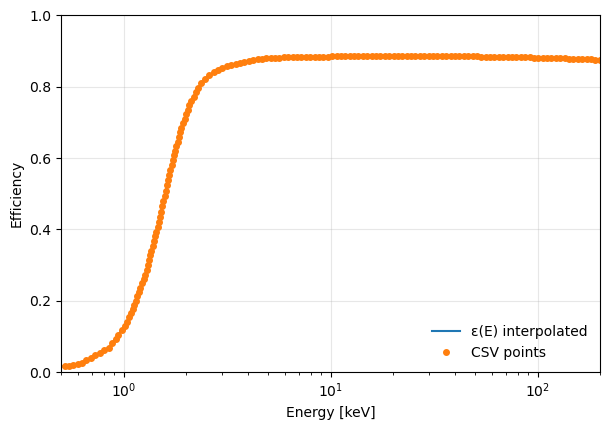

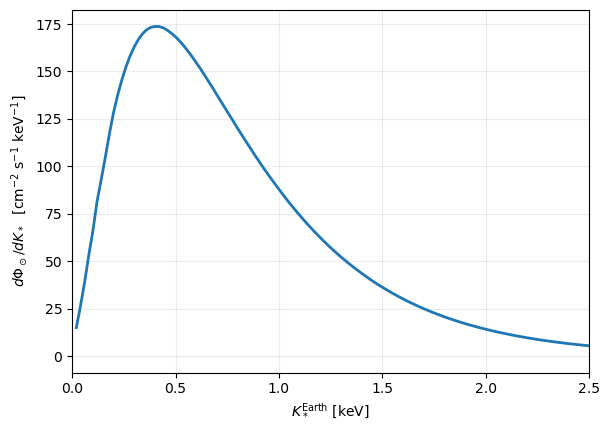

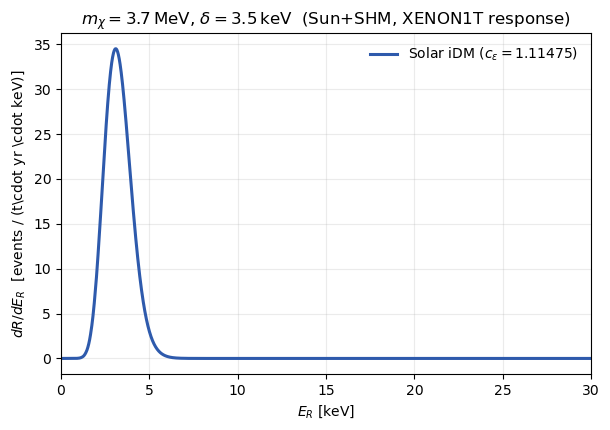

Total events in [0,30] keV (with response): 65.06  per t·yr


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# ========================== Numerics / small helpers ==========================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

# ========================= Constants / geometry / detector ====================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30                  # local halo density
SEC_PER_YR    = 365.25*24*3600.0

# Halo (SHM) in the Sun frame
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    """ SHM speed PDF g(u) (not yet normalised), Sun frame, truncated at v_esc_gal. """
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=80):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# ============================== Solar profiles ===============================
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

n_e0   = 6.0e25           # cm^-3
T0_keV = 1.30             # keV
def shape_r(r_cm):
    x = r_cm/R_sun_cm
    return (1.0 - x*x)**2
def n_e_of_r(r_cm):  return n_e0 * shape_r(r_cm)
def T_of_r(r_cm):    return T0_keV*(0.7 + 0.3*shape_r(r_cm))

# ============================= Masses & units ================================
m_e_keV  = 511.0
GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GeV = 1.0e6

# ======================= Thermal-line normalisation (paper) ==================
def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    ε = (c_eps × 1e-4) * (mχ/0.1 GeV) * ((mA'/mχ)/3)^2 * (αD/0.5)^(-1/2)
    y = ε^2 α_D / r^4
    σ_e = 16 π α_em μ^2 y / mχ^4   (contact limit), in cm^2.
    """
    me_GeV   = m_e_keV*1e-6
    mchi_GeV = float(mchi_GeV)
    mu_GeV   = (mchi_GeV*me_GeV)/(mchi_GeV+me_GeV)
    eps = (c_eps*1.0e-4)*(mchi_GeV/0.1)*((r_ratio)/3.0)**2*(alpha_D/0.5)**(-0.5)
    y   = (eps**2)*alpha_D/(r_ratio**4)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2*GEV2_TO_CM2

# ============ dGamma/dv2 per (n σ) with angular cap (q-integral) ============
def dGamma_dv2_per_nsigma(r_cm, vchi, v2, mchi_keV, mT_keV, delta_keV,
                          qN=320, qsigma=10.0):
    """
    Differential escape rate density (per target, per σ_tot) at fixed v2,
    including the exact escape cap implemented at the q-level.
    Returns a dimensionless factor to be used with the *local* density weight.
    """
    if v2 <= 0.0 or vchi <= 0.0:
        return 0.0

    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)

    if v2 < (Kesc/mchi_keV):
        return 0.0

    # q-range (Gaussian tail cut safely at ~qsigma p0 above upper edge)
    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))

    # cosθ implied by (v2, q)
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v2*v2 - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in):
        return 0.0
    costh = np.clip(costh, -1.0, 1.0)

    # Thermal average integrand
    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    # NOTE: projector already carries 1/vchi; we will weight with vchi later (local density)
    integrand = (mchi_keV*v2)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

# ====================== dΦ/dK* at Earth from Sun + SHM =======================
def dphi_dKstar_earth(Kgrid_keV, mchi_GeV, delta_keV, *,
                      Nr=40, Nvinf=128, qN=320,
                      alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    dΦ/dK_*^Earth for χ* produced by e–χ in the Sun and escaping to Earth.
    Returns [cm^-2 s^-1 keV^-1].
    """
    # grids
    r  = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)   # reuse one SHM grid

    # constants & cross section (electrons)
    mchi_keV = mchi_GeV * 1e6
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

    # number density at infinity (cm^-3) and one factor of c to convert “one speed”
    n_inf     = rho0_GeVcm3 / (mchi_GeV + 1e-300)  # cm^-3
    speed_to_rate = C_LIGHT                        # cm/s

    # Sun→Earth geometric dilution
    geom = 1.0 / (4.0 * np.pi * AU_cm**2)

    out = np.zeros_like(Kgrid_keV, dtype=float)

    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri in r:
            ne   = n_e_of_r(ri)
            vesc = vesc_of_r(ri)                                   # c-units
            v2   = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))  # post-scatter local speed
            if not np.isfinite(v2) or v2 <= vesc:
                continue

            # Jacobian dv/dK_* (at fixed r)
            dv_dK = 1.0 / (mchi_keV * v2 + 1e-300)                 # keV^-1

            # average over incoming speeds with the **local-density** weight vχ g(u)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)           # local pre-scatter speeds
            Gamma_vals = np.array(
                [dGamma_dv2_per_nsigma(ri, vc, v2, mchi_keV, m_e_keV, delta_keV, qN=qN)
                 for vc in vchi_grid], dtype=float
            )
            # <<< KEY FIX: gravitational focusing weight vchi * g(u), not u * g(u)
            density_weight = vchi_grid * gpdf
            avg = trapz(density_weight * Gamma_vals, ugrid)

            # volumetric production at this shell into the K-bin
            shell_sum += (4.0*np.pi*ri*ri) * ne * sigma_e * avg * dv_dK * dr

        out[iK] = n_inf * speed_to_rate * geom * shell_sum

    return out  # [cm^-2 s^-1 keV^-1]

# =================== Detector kernel & event spectrum dR/dER ==================
def mu_keV(mchi_GeV):  # χ–e
    mchi_keV = mchi_GeV*KEV_PER_GeV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def dsdER_electron(mchi_GeV, K_keV, *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0):
    """
    dσ/dE_R for χ*–e → χ–e at the detector (contact limit):
      dσ/dE_R ≈ σ_e * m_e / (2 μ^2 v^2),   v^2 = 2K/mχ.
    Returns cm^2/keV.
    """
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    v2       = np.maximum(2.0*K_keV/(mchi_keV + _EPS), 1e-30)
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    return sigma_e * (m_e_keV/(2.0*mu*mu*v2))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    """
    Minimal incoming K* to produce a recoil ER at the detector (exact two-body kinematics):
      v_min(ER) = |(m_e/μ) ER − δ| / sqrt(2 m_e ER),   Kmin = 1/2 mχ v_min^2.
    """
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV, K_grid_keV, dphi_dK_keV,
                    *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0,
                    NT_per_ton = (6.022_140_76e23 * 26 / 131.293) * 1.0e6):
    """
    Fold the solar χ* flux (at Earth) with the detector kernel to get dR/dER.
    dphi_dK_keV: cm^-2 s^-1 keV^-1 on the grid K_grid_keV.
    Returns events / (t·yr·keV).
    """
    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid_keV >= Kmin
        if not np.any(m):
            continue
        dsdER = dsdER_electron(mchi_GeV, K_grid_keV[m], c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
        integ = trapz(dphi_dK_keV[m]*dsdER, K_grid_keV[m])   # s^-1 per target
        out[i] = NT_per_ton * integ * SEC_PER_YR
    return out

# =================== XENON1T resolution + efficiency (CSV) ===================
A_RES = 0.313   # sqrt(keV)
B_RES = 0.0017
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def load_efficiency_csv(csv_path):
    # two columns: Energy_keV, Efficiency
    try:
        arr = np.genfromtxt(csv_path, delimiter=",", comments="#")
        if arr.ndim == 1: raise ValueError
    except Exception:
        arr = np.genfromtxt(csv_path, delimiter=";", comments="#")
        if arr.ndim == 1: raise
    E = np.asarray(arr[:,0], float); eps = np.asarray(arr[:,1], float)
    m = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
    E, eps = E[m], _clip01(eps[m])
    idx = np.argsort(E); E, eps = E[idx], eps[idx]
    return E, eps

def build_efficiency_from_csv(csv_path):
    candidates = [csv_path]
    if csv_path.startswith("\\\\wsl.localhost\\Ubuntu\\"):
        candidates.append(csv_path.replace("\\\\wsl.localhost\\Ubuntu", "").replace("\\", "/"))
    candidates.append(os.path.basename(csv_path))

    last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                E, eps = load_efficiency_csv(p)
                print(f"[ε] Loaded efficiency from: {p}")
                break
        except Exception as e:
            last_err = e
    else:
        raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")

    logE = np.log(E)
    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), E[0]*1e-6))
        vals = np.interp(x, logE, eps, left=eps[0], right=eps[-1])
        return _clip01(vals)
    return eps_func, (E, eps)

def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec = np.asarray(ER_rec, float)

    sig = sigma_res_keV(Etrue)[None, :]
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/np.maximum(sig,1e-12))**2)/(np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)

    dE      = np.gradient(Etrue)
    S_smear = (G*(S[None,:]*dE[None,:])).sum(axis=1)
    S_vis   = eps_func(Erec)*S_smear
    return Erec, S_vis, S_smear

# =================================== Main ====================================
if __name__ == "__main__":
    # ---- benchmark (paper Fig. 5) ----
    mchi_MeV   = 3.7
    delta_keV  = 3.5
    mchi_GeV   = mchi_MeV*1e-3

    c_eps      = 1.11475
    alpha_D    = 0.5
    r_ratio    = 3.0

    # ---- efficiency CSV (your digitization) ----
    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"
    eps_func, (Epts, epspts) = build_efficiency_from_csv(CSV_PATH)

    # ---- K* grid (arriving at Earth) and ER grid ----
    K_max_keV  = 40
    NK         = 2000
    K_grid_keV = np.linspace(0.02, K_max_keV, NK)
    ER_true    = np.linspace(0.02, 30.0, 2401)

    # ---- solar χ* flux at Earth, differential in K* ----
    dphi_dK = dphi_dKstar_earth(K_grid_keV, mchi_GeV, delta_keV,
                                Nr=40, Nvinf=128, qN=320,
                                alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

    # ---- event spectrum (unsmeared) ----
    dRdER_true = dRdER_from_flux(mchi_GeV, delta_keV, ER_true,
                                 K_grid_keV, dphi_dK,
                                 c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)

    # ---- apply XENON1T response ----
    ER_rec = ER_true.copy()
    ER_rec, dRdER_vis, _ = smear_and_apply_eff(ER_true, dRdER_true, eps_func, ER_rec)

    # ---- plots ----
    # efficiency sanity check
    Eplot = np.logspace(np.log10(max(0.5, Epts[0]*0.9)), 2.5, 400)
    plt.figure(figsize=(6.2,4.4))
    plt.semilogx(Eplot, eps_func(Eplot), label="ε(E) interpolated")
    plt.semilogx(Epts, epspts, "o", ms=4, label="CSV points")
    plt.xlim(0.5, 200); plt.ylim(0,1)
    plt.xlabel("Energy [keV]"); plt.ylabel("Efficiency")
    plt.grid(alpha=0.3); plt.legend(frameon=False); plt.tight_layout(); plt.show()

    # dΦ/dK* (Earth)
    plt.figure(figsize=(6.2,4.4))
    plt.plot(K_grid_keV, dphi_dK, lw=2)
    plt.xlabel(r"$K_*^{\rm Earth}$ [keV]")
    plt.ylabel(r"$d\Phi_\odot/dK_*$  [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
    plt.xlim(0, 2.5); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

    # dR/dER with response
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    ax.plot(ER_rec, dRdER_vis, lw=2.2, color="#2e5aac",
            label=fr"Solar iDM ($c_\epsilon={c_eps:g}$)")
    ax.set_xlabel(r"$E_R$ [keV]")
    ax.set_ylabel(r"$dR/dE_R$  [events / (t\cdot yr \cdot keV)]")
    ax.set_xlim(0, 30); ax.grid(alpha=0.25); ax.legend(frameon=False)
    ax.set_title(rf"$m_\chi={mchi_MeV}\,$MeV, $\delta={delta_keV}\,$keV  (Sun+SHM, XENON1T response)")
    plt.tight_layout(); plt.show()

    print(f"Total events in [0,30] keV (with response): {trapz(dRdER_vis, ER_rec):.2f}  per t·yr")

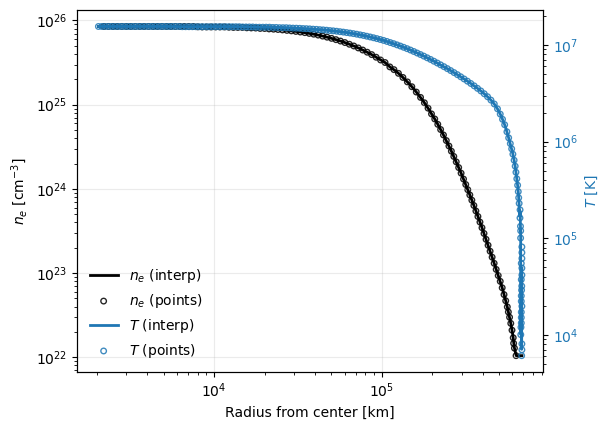

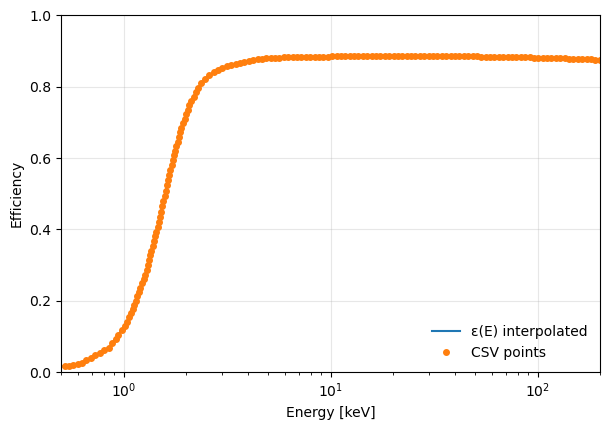

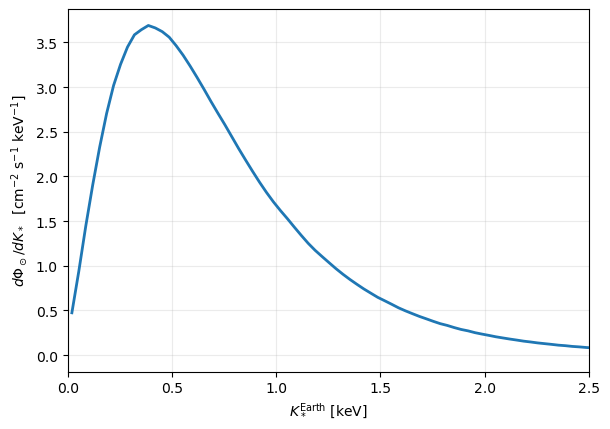

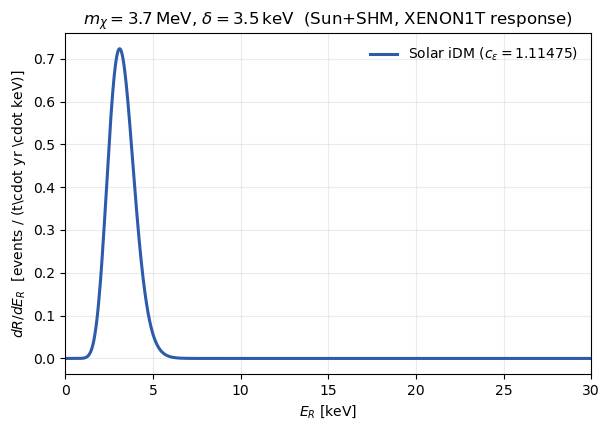

Total events in [0,30] keV (with response): 1.34  per t·yr


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# ========================== Numerics / small helpers ==========================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

def _load_two_col_csv(path):
    """Load two-column CSV (x,y). Accepts ',' or ';' separators."""
    try:
        arr = np.genfromtxt(path, delimiter=",", comments="#")
        if arr.ndim == 1: raise ValueError
    except Exception:
        arr = np.genfromtxt(path, delimiter=";", comments="#")
        if arr.ndim == 1: raise
    x = np.asarray(arr[:, 0], float)
    y = np.asarray(arr[:, 1], float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    return x[idx], y[idx]

def _make_interp(x, y, *, logx=False, logy=False, clip_low=None, clip_high=None):
    """
    Build a 1D interpolator with optional log-x/log-y. Outside range -> clip to edges.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)

    if logx:
        x = np.where(x > 0, x, np.nan)
        if not np.all(np.isfinite(x)):
            raise ValueError("logx requested but x has non-positive values.")
        x_eval = np.log(x)
    else:
        x_eval = x

    if logy:
        if np.any(y <= 0):
            logy = False
            y_eval = y
        else:
            y_eval = np.log(y)
    else:
        y_eval = y

    xmin, xmax = x_eval[0], x_eval[-1]

    def f(xq):
        xq = np.asarray(xq, float)
        xq_eval = np.log(xq) if logx else xq
        xq_eval = np.clip(xq_eval, xmin, xmax)  # clip outside to edges
        vals = np.interp(xq_eval, x_eval, y_eval)
        if logy:
            vals = np.exp(vals)
        if clip_low is not None or clip_high is not None:
            vals = np.clip(vals,
                           clip_low if clip_low is not None else -np.inf,
                           clip_high if clip_high is not None else  np.inf)
        return vals

    return f

# ========================= Constants / geometry / detector ====================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30                  # local halo density
SEC_PER_YR    = 365.25*24*3600.0

# Halo (SHM) in the Sun frame
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    """ SHM speed PDF g(u) (not yet normalised), Sun frame, truncated at v_esc_gal. """
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=80):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# ============================== Solar profiles ===============================
# Escape-speed profile (kept simple: quadratic between core & surface)
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

# --- NEW: load T(r) [K] and n_e(r) [cm^-3] from CSVs with radius in km ---
KELVIN_PER_keV = 1.160451812e7  # 1 keV ≈ 1.16045e7 K
KM_TO_CM = 1.0e5

TEMP_CSV = "Temperature as a function of the radius.csv"             # [km, K]
NE_CSV   = "Electron number density as a function of the radius.csv" # [km, cm^-3]

# Temperature
_r_km_T, _T_K = _load_two_col_csv(TEMP_CSV)
_T_keV = _T_K / KELVIN_PER_keV
_r_cm_T = _r_km_T * KM_TO_CM
T_of_r  = _make_interp(_r_cm_T, _T_keV, logx=False, logy=False)

# Electron density
_r_km_ne, _ne_cm3 = _load_two_col_csv(NE_CSV)
_r_cm_ne = _r_km_ne * KM_TO_CM
n_e_of_r = _make_interp(_r_cm_ne, _ne_cm3, logx=False, logy=False)

# ============================= Masses & units ================================
m_e_keV  = 511.0
GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GeV = 1.0e6

# ======================= Thermal-line normalisation (paper) ==================
def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    ε = (c_eps × 1e-4) * (mχ/0.1 GeV) * ((mA'/mχ)/3)^2 * (αD/0.5)^(-1/2)
    y = ε^2 α_D / r^4
    σ_e = 16 π α_em μ^2 y / mχ^4   (contact limit), in cm^2.
    """
    me_GeV   = m_e_keV*1e-6
    mchi_GeV = float(mchi_GeV)
    mu_GeV   = (mchi_GeV*me_GeV)/(mchi_GeV+me_GeV)
    eps = (c_eps*1.0e-4)*(mchi_GeV/0.1)*((r_ratio)/3.0)**2*(alpha_D/0.5)**(-0.5)
    y   = (eps**2)*alpha_D/(r_ratio**4)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2*GEV2_TO_CM2

# ============ dGamma/dv2 per (n σ) with angular cap (q-integral) ============
def dGamma_dv2_per_nsigma(r_cm, vchi, v2, mchi_keV, mT_keV, delta_keV,
                          qN=320, qsigma=10.0):
    """Escape-rate density (per target, per σ_tot) at fixed v2 (dimensionless)."""
    if v2 <= 0.0 or vchi <= 0.0:
        return 0.0

    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)

    if v2 < (Kesc/mchi_keV):
        return 0.0

    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))

    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v2*v2 - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in):
        return 0.0
    costh = np.clip(costh, -1.0, 1.0)

    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    integrand = (mchi_keV*v2)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

# ====================== dΦ/dK* at Earth from Sun + SHM =======================
def dphi_dKstar_earth(Kgrid_keV, mchi_GeV, delta_keV, *,
                      Nr=40, Nvinf=128, qN=320,
                      alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """dΦ/dK_*^Earth for χ* produced by e–χ in the Sun and escaping to Earth."""
    r  = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)

    mchi_keV = mchi_GeV * 1e6
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    n_inf     = rho0_GeVcm3 / (mchi_GeV + 1e-300)  # cm^-3
    speed_to_rate = C_LIGHT                        # cm/s
    geom = 1.0 / (4.0 * np.pi * AU_cm**2)

    out = np.zeros_like(Kgrid_keV, dtype=float)
    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri in r:
            ne   = n_e_of_r(ri)
            vesc = vesc_of_r(ri)
            v2   = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v2) or v2 <= vesc:
                continue

            dv_dK = 1.0 / (mchi_keV * v2 + 1e-300)

            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)
            Gamma_vals = np.array(
                [dGamma_dv2_per_nsigma(ri, vc, v2, mchi_keV, m_e_keV, delta_keV, qN=qN)
                 for vc in vchi_grid], dtype=float
            )
            density_weight = vchi_grid * gpdf
            avg = trapz(density_weight * Gamma_vals, ugrid)

            shell_sum += (4.0*np.pi*ri*ri) * ne * sigma_e * avg * dv_dK * dr

        out[iK] = n_inf * speed_to_rate * geom * shell_sum

    return out  # [cm^-2 s^-1 keV^-1]

# =================== Detector kernel & event spectrum dR/dER ==================
def mu_keV(mchi_GeV):  # χ–e
    mchi_keV = mchi_GeV*KEV_PER_GeV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def dsdER_electron(mchi_GeV, K_keV, *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0):
    """dσ/dE_R ≈ σ_e * m_e / (2 μ^2 v^2), v^2 = 2K/mχ.  Returns cm^2/keV."""
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    v2       = np.maximum(2.0*K_keV/(mchi_keV + _EPS), 1e-30)
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    return sigma_e * (m_e_keV/(2.0*mu*mu*v2))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    """Kmin from exact two-body kinematics."""
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV, K_grid_keV, dphi_dK_keV,
                    *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0,
                    NT_per_ton = (6.022_140_76e23 * 26 / 131.293) * 1.0e6):
    """Fold the solar χ* flux with the detector kernel to get dR/dER (events / t·yr·keV)."""
    out = np.zeros_like(ER_grid_keV, dtype=float)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid_keV >= Kmin
        if not np.any(m):
            continue
        dsdER = dsdER_electron(mchi_GeV, K_grid_keV[m], c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
        integ = trapz(dphi_dK_keV[m]*dsdER, K_grid_keV[m])   # s^-1 per target
        out[i] = NT_per_ton * integ * SEC_PER_YR
    return out

# =================== XENON1T resolution + efficiency (CSV) ===================
A_RES = 0.313   # sqrt(keV)
B_RES = 0.0017
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def build_efficiency_from_csv(csv_path):
    """Efficiency CSV with columns: Energy_keV, Efficiency (0..1)."""
    E, eps = _load_two_col_csv(csv_path)
    eps = _clip01(eps)
    eps_func = _make_interp(E, eps, logx=True, logy=False, clip_low=0.0, clip_high=1.0)
    return eps_func, (E, eps)

def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec = np.asarray(ER_rec, float)

    sig = sigma_res_keV(Etrue)[None, :]
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/np.maximum(sig,1e-12))**2)/(np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)

    dE      = np.gradient(Etrue)
    S_smear = (G*(S[None,:]*dE[None,:])).sum(axis=1)
    S_vis   = eps_func(Erec)*S_smear
    return Erec, S_vis, S_smear

# =================================== Main ====================================
if __name__ == "__main__":
    # ---- benchmark (paper Fig. 5) ----
    mchi_MeV   = 3.7
    delta_keV  = 3.5
    mchi_GeV   = mchi_MeV*1e-3

    c_eps      = 1.11475
    alpha_D    = 0.5
    r_ratio    = 3.0

    # ---- efficiency CSV (your digitization) ----
    EFF_CSV = r"Efficiency curve digitization.csv"
    eps_func, (Epts, epspts) = build_efficiency_from_csv(EFF_CSV)

    # ---- K* grid (arriving at Earth) and ER grid ----
    K_max_keV  = 100.0
    NK         = 3000
    K_grid_keV = np.linspace(0.02, K_max_keV, NK)
    ER_true    = np.linspace(0.02, 30.0, 2401)

    # ---- solar χ* flux at Earth, differential in K* ----
    dphi_dK = dphi_dKstar_earth(K_grid_keV, mchi_GeV, delta_keV,
                                Nr=40, Nvinf=128, qN=320,
                                alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

    # ---- event spectrum (unsmeared) ----
    dRdER_true = dRdER_from_flux(mchi_GeV, delta_keV, ER_true,
                                 K_grid_keV, dphi_dK,
                                 c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)

    # ---- apply XENON1T response ----
    ER_rec = ER_true.copy()
    ER_rec, dRdER_vis, _ = smear_and_apply_eff(ER_true, dRdER_true, eps_func, ER_rec)

    # ===================== PLOTS: digitized + interpolated ====================
    # Solar profiles: T(r) and n_e(r) together with twin y-axes
    r_km_min = max(min(_r_km_T.min(), _r_km_ne.min()), 0.0)
    r_km_max = min(max(_r_km_T.max(), _r_km_ne.max()), R_sun_cm/1e5)
    r_km_plot = np.linspace(r_km_min, r_km_max, 600)
    r_cm_plot = r_km_plot * 1e5
    T_K_interp  = T_of_r(r_cm_plot) * KELVIN_PER_keV
    ne_interp   = n_e_of_r(r_cm_plot)

    fig, ax1 = plt.subplots(figsize=(6.2, 4.4))
    ax2 = ax1.twinx()

    # n_e (left)
    ax1.set_yscale("log")
    ax1.loglog(r_km_plot, ne_interp, lw=2.0, color="black", label=r"$n_e$ (interp)")
    ax1.scatter(_r_km_ne, _ne_cm3, s=16, facecolors="none", edgecolors="black", alpha=0.85,
                label=r"$n_e$ (points)")
    ax1.set_ylabel(r"$n_e\ {\rm [cm^{-3}]}$", color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # T (right)
    ax2.set_yscale("log")
    ax2.loglog(r_km_plot, T_K_interp, lw=2.0, color="tab:blue", label=r"$T$ (interp)")
    ax2.scatter(_r_km_T, _T_K, s=16, facecolors="none", edgecolors="tab:blue", alpha=0.85,
                label=r"$T$ (points)")
    ax2.set_ylabel(r"$T\ {\rm [K]}$", color="tab:blue")
    ax2.tick_params(axis='y', labelcolor="tab:blue")

    ax1.set_xlabel("Radius from center [km]")
    ax1.grid(alpha=0.25)
    # combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="best", frameon=False)
    plt.tight_layout(); plt.show()

    # Efficiency sanity check (digitized points + interpolated curve)
    Eplot = np.logspace(np.log10(max(0.5, Epts[0]*0.9)), 2.5, 400)
    plt.figure(figsize=(6.2,4.4))
    plt.semilogx(Eplot, eps_func(Eplot), label="ε(E) interpolated")
    plt.semilogx(Epts, epspts, "o", ms=4, label="CSV points")
    plt.xlim(0.5, 200); plt.ylim(0,1)
    plt.xlabel("Energy [keV]"); plt.ylabel("Efficiency")
    plt.grid(alpha=0.3); plt.legend(frameon=False); plt.tight_layout(); plt.show()

    # dΦ/dK* (Earth)
    plt.figure(figsize=(6.2,4.4))
    plt.plot(K_grid_keV, dphi_dK, lw=2)
    plt.xlabel(r"$K_*^{\rm Earth}$ [keV]")
    plt.ylabel(r"$d\Phi_\odot/dK_*$  [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
    plt.xlim(0, 2.5); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

    # dR/dER with response
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    ax.plot(ER_rec, dRdER_vis, lw=2.2, color="#2e5aac",
            label=fr"Solar iDM ($c_\epsilon={c_eps:g}$)")
    ax.set_xlabel(r"$E_R$ [keV]")
    ax.set_ylabel(r"$dR/dE_R$  [events / (t\cdot yr \cdot keV)]")
    ax.set_xlim(0, 30); ax.grid(alpha=0.25); ax.legend(frameon=False)
    ax.set_title(rf"$m_\chi={mchi_MeV}\,$MeV, $\delta={delta_keV}\,$keV  (Sun+SHM, XENON1T response)")
    plt.tight_layout(); plt.show()

    print(f"Total events in [0,30] keV (with response): {trapz(dRdER_vis, ER_rec):.2f}  per t·yr")

[ε] Loaded efficiency from: /home/dtinocov/University/UD_2025/Efficiency curve digitization.csv
[225/225] points


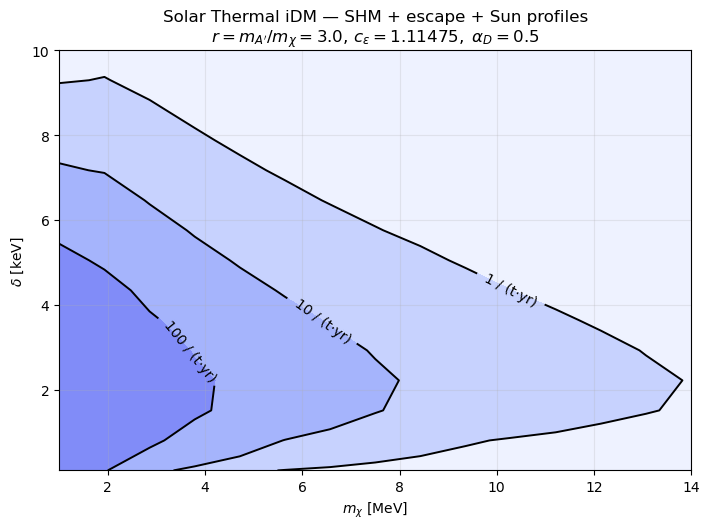

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from concurrent.futures import ProcessPoolExecutor, as_completed

# ========================== Numerics / small helpers ==========================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

# ========================= Constants / geometry / detector ====================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30                  # local halo density
SEC_PER_YR    = 365.25*24*3600.0

# Halo (SHM) in the Sun frame
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    """ SHM speed PDF g(u) (not yet normalised), Sun frame, truncated at v_esc_gal. """
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=128):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# ============================== Solar profiles ===============================
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

n_e0   = 6.0e25           # cm^-3
T0_keV = 1.30             # keV
def shape_r(r_cm):
    x = r_cm/R_sun_cm
    return (1.0 - x*x)**2
def n_e_of_r(r_cm):  return n_e0 * shape_r(r_cm)
def T_of_r(r_cm):    return T0_keV*(0.7 + 0.3*shape_r(r_cm))

# ============================= Masses & units ================================
m_e_keV  = 511.0
GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GeV = 1.0e6

# ======================= Thermal-line normalisation (paper) ==================
def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    ε = (c_eps × 1e-4) * (mχ/0.1 GeV) * ((mA'/mχ)/3)^2 * (αD/0.5)^(-1/2)
    y = ε^2 α_D / r^4
    σ_e = 16 π α_em μ^2 y / mχ^4   (contact limit), in cm^2.
    """
    me_GeV   = m_e_keV*1e-6
    mchi_GeV = float(mchi_GeV)
    mu_GeV   = (mchi_GeV*me_GeV)/(mchi_GeV+me_GeV)
    eps = (c_eps*1.0e-4)*(mchi_GeV/0.1)*((r_ratio)/3.0)**2*(alpha_D/0.5)**(-0.5)
    y   = (eps**2)*alpha_D/(r_ratio**4)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2*GEV2_TO_CM2

# ============ dGamma/dv per (n σ) with angular cap (q-integral) ============
def dGamma_dv_per_nsigma(r_cm, vchi, v_local, mchi_keV, mT_keV, delta_keV,
                         qN=240, qsigma=10.0):
    """ Per-target, per-σ_tot differential escape rate density at fixed local speed v_local. """
    if v_local <= 0.0 or vchi <= 0.0:
        return 0.0
    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)
    if v_local < (Kesc/mchi_keV):
        return 0.0
    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v_local*v_local - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in):
        return 0.0
    costh = np.clip(costh, -1.0, 1.0)
    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    integrand = (mchi_keV*v_local)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

# ====================== dΦ/dK* at Earth from Sun + SHM =======================
def dphi_dKstar_earth(Kgrid_keV, mchi_GeV, delta_keV, *,
                      Nr=32, Nvinf=96, qN=240,
                      alpha_D=0.5, r_ratio=3.0, c_eps=1.11475,
                      cached=None):
    """ dΦ/dK_*^Earth; [cm^-2 s^-1 keV^-1]. """
    if cached and "r" in cached:
        r  = cached["r"];  dr = cached["dr"]
        ugrid, gpdf = cached["ugrid"], cached["gpdf"]
        ne_r, vesc_r = cached["ne_r"], cached["vesc_r"]
    else:
        r  = np.linspace(0.0, R_sun_cm, Nr)
        dr = r[1] - r[0] if Nr > 1 else R_sun_cm
        ugrid, gpdf = make_speed_pdf_grid(Nvinf)
        ne_r  = n_e_of_r(r)
        vesc_r= vesc_of_r(r)
        if cached is not None:
            cached.update(dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf,
                               ne_r=ne_r, vesc_r=vesc_r))

    mchi_keV = mchi_GeV * 1e6
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    n_inf     = rho0_GeVcm3 / (mchi_GeV + 1e-300)  # cm^-3
    geom = 1.0 / (4.0 * np.pi * AU_cm**2)
    out = np.zeros_like(Kgrid_keV, dtype=float)

    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri, ne, vesc in zip(r, ne_r, vesc_r):
            v_local = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v_local) or v_local <= vesc:
                continue
            dv_dK = 1.0 / (mchi_keV * v_local + 1e-300)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)
            Gamma_vals = np.array(
                [dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_e_keV, delta_keV, qN=qN)
                 for vc in vchi_grid], dtype=float
            )
            density_weight = vchi_grid * gpdf
            avg = trapz(density_weight * Gamma_vals, ugrid)
            shell_sum += (4.0*np.pi*ri*ri) * ne * sigma_e * avg * dv_dK * dr

        out[iK] = n_inf * C_LIGHT * geom * shell_sum

    return out

# =================== Detector kernel & event spectrum dR/dER ==================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def dsdER_electron(mchi_GeV, K_keV, *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    v2       = np.maximum(2.0*K_keV/(mchi_keV + _EPS), 1e-30)
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    return sigma_e * (m_e_keV/(2.0*mu*mu*v2))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV, K_grid_keV, dphi_dK_keV,
                    *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0,
                    NT_per_ton = (6.022_140_76e23 * 26 / 131.293) * 1.0e6):
    out = np.zeros_like(ER_grid_keV, dtype=float)
    dsdER = dsdER_electron(mchi_GeV, K_grid_keV, c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid_keV >= Kmin
        if not np.any(m): 
            continue
        integ = trapz(dphi_dK_keV[m]*dsdER[m], K_grid_keV[m])   # s^-1 per target
        out[i] = NT_per_ton * integ * SEC_PER_YR
    return out

# =================== XENON1T resolution + efficiency (CSV) ===================
A_RES = 0.313
B_RES = 0.0017
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def load_efficiency_csv(csv_path):
    try:
        arr = np.genfromtxt(csv_path, delimiter=",", comments="#")
        if arr.ndim == 1: raise ValueError
    except Exception:
        arr = np.genfromtxt(csv_path, delimiter=";", comments="#")
        if arr.ndim == 1: raise
    E = np.asarray(arr[:,0], float); eps = np.asarray(arr[:,1], float)
    m = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
    E, eps = E[m], _clip01(eps[m])
    idx = np.argsort(E); E, eps = E[idx], eps[idx]
    return E, eps

def build_efficiency_from_csv(csv_path):
    candidates = [csv_path]
    if csv_path.startswith("\\\\wsl.localhost\\Ubuntu\\"):
        candidates.append(csv_path.replace("\\\\wsl.localhost\\Ubuntu", "").replace("\\", "/"))
    candidates.append(os.path.basename(csv_path))
    last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                E, eps = load_efficiency_csv(p)
                print(f"[ε] Loaded efficiency from: {p}")
                break
        except Exception as e:
            last_err = e
    else:
        raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")
    logE = np.log(E)
    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), E[0]*1e-6))
        vals = np.interp(x, logE, eps, left=eps[0], right=eps[-1])
        return _clip01(vals)
    return eps_func, (E, eps)

def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec = np.asarray(ER_rec, float)
    sig = sigma_res_keV(Etrue)[None, :]
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/np.maximum(sig,1e-12))**2)/(np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)
    dE      = np.gradient(Etrue)
    S_smear = (G*(S[None,:]*dE[None,:])).sum(axis=1)
    S_vis   = eps_func(Erec)*S_smear
    return Erec, S_vis, S_smear

# ========================== Map builder (events / t·yr) ======================
def total_events_tyr(mchi_GeV, delta_keV, eps_func, *,
                     K_grid_keV, ER_grid_keV,
                     Nr=32, Nvinf=96, qN=240,
                     alpha_D=0.5, r_ratio=3.0, c_eps=1.11475,
                     cached=None):
    dphi_dK = dphi_dKstar_earth(K_grid_keV, mchi_GeV, delta_keV,
                                Nr=Nr, Nvinf=Nvinf, qN=qN,
                                alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps,
                                cached=cached)
    dRdER_true = dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV,
                                 K_grid_keV, dphi_dK,
                                 c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    ER_rec, dRdER_vis, _ = smear_and_apply_eff(ER_grid_keV, dRdER_true, eps_func, ER_grid_keV)
    return float(trapz(dRdER_vis, ER_rec))

# ========================== Parallel infrastructure ==========================
# Globals populated in worker initializer
_CACHE = None
_KGRID = None
_ERGRID = None
_EPS_FUNC = None
_CONFIG = None

def _init_worker(cache, Kgrid, ERgrid, Epts, epspts, config):
    """Initializer: runs once per process."""
    import numpy as _np
    global _CACHE, _KGRID, _ERGRID, _EPS_FUNC, _CONFIG
    _CACHE = cache
    _KGRID = Kgrid
    _ERGRID = ERgrid
    _CONFIG = config
    logE = _np.log(Epts)
    def eps_func_local(EkeV):
        x = _np.log(_np.maximum(_np.asarray(EkeV, float), Epts[0]*1e-6))
        vals = _np.interp(x, logE, epspts, left=epspts[0], right=epspts[-1])
        return _np.clip(vals, 0.0, 1.0)
    _EPS_FUNC = eps_func_local

def _task_point(idx_pair_m_d):
    """Worker: compute total events at one (mχ, δ) point."""
    (ix, iy, m_GeV, d_keV) = idx_pair_m_d
    Rval = total_events_tyr(m_GeV, d_keV, _EPS_FUNC,
                            K_grid_keV=_KGRID, ER_grid_keV=_ERGRID,
                            Nr=_CONFIG["Nr"], Nvinf=_CONFIG["Nvinf"], qN=_CONFIG["qN"],
                            alpha_D=_CONFIG["alpha_D"], r_ratio=_CONFIG["r_ratio"], c_eps=_CONFIG["c_eps"],
                            cached=_CACHE)
    return ix, iy, Rval

def build_shared_cache(Nr, Nvinf):
    """Precompute Sun/SHM arrays once in the parent; copy-on-fork to workers."""
    r  = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)
    ne_r  = n_e_of_r(r)
    vesc_r= vesc_of_r(r)
    return dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf, ne_r=ne_r, vesc_r=vesc_r)

# =================================== Main ====================================
if __name__ == "__main__":
    # --- model constants (kept fixed across the scan) ---
    c_eps   = 1.11475
    alpha_D = 0.5
    r_ratio = 3.0

    # --- efficiency CSV (digitized XENON1T total ε) ---
    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"
    eps_func, (Epts, epspts) = build_efficiency_from_csv(CSV_PATH)

    # --- grids ---
    K_max_keV  = 60.0
    NK         = 1000
    K_grid_keV = np.linspace(0.02, K_max_keV, NK)
    ER_grid_keV = np.linspace(0.02, 30.0, 2001)

    # parameter-space grid
    mchi_vals_MeV  = np.linspace(1.0, 14.0, 15)     # x-axis
    delta_vals_keV = np.linspace(0.1, 10.0, 15)     # y-axis

    # physics / integration knobs
    Nr, Nvinf, qN = 40, 128, 320

    # --- shared caches to reuse SHM + solar profiles ---
    shared_cache = build_shared_cache(Nr, Nvinf)

    # --- parallel config ---
    NPROC = max(1, os.cpu_count() - 1)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")

    R = np.zeros((delta_vals_keV.size, mchi_vals_MeV.size), dtype=float)

    if NPROC == 1:
        # Sequential fallback
        for ix, m_MeV in enumerate(mchi_vals_MeV):
            m_GeV = m_MeV*1e-3
            for iy, d_keV in enumerate(delta_vals_keV):
                R[iy, ix] = total_events_tyr(m_GeV, d_keV, eps_func,
                                             K_grid_keV=K_grid_keV, ER_grid_keV=ER_grid_keV,
                                             Nr=Nr, Nvinf=Nvinf, qN=qN,
                                             alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps,
                                             cached=shared_cache)
    else:
        # Build task list
        tasks = []
        for ix, m_MeV in enumerate(mchi_vals_MeV):
            m_GeV = m_MeV*1e-3
            for iy, d_keV in enumerate(delta_vals_keV):
                tasks.append((ix, iy, m_GeV, d_keV))

        config = dict(Nr=Nr, Nvinf=Nvinf, qN=qN,
                      alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

        done = 0
        step = max(1, len(tasks)//40)

        with ProcessPoolExecutor(max_workers=NPROC,
                                 initializer=_init_worker,
                                 initargs=(shared_cache, K_grid_keV, ER_grid_keV, Epts, epspts, config)) as ex:
            futures = [ex.submit(_task_point, t) for t in tasks]
            for fut in as_completed(futures):
                ix, iy, val = fut.result()
                R[iy, ix] = val
                done += 1
                if (done % step == 0) or (done == len(tasks)):
                    print(f"\r[{done}/{len(tasks)}] points", end="", flush=True)
        print()

    # --- plot: parameter space like Fig. 6 (left) ---
    LEVELS = [1.0, 10.0, 100.0]   # events per t·yr
    fig, ax = plt.subplots(figsize=(7.2, 5.4))

    cf = ax.contourf(mchi_vals_MeV, delta_vals_keV, R,
                     levels=[0.0] + LEVELS + [R.max()*1.01],
                     colors=["#eef2ff", "#c7d2fe", "#a5b4fc", "#818cf8"])
    cs = ax.contour(mchi_vals_MeV, delta_vals_keV, R,
                    levels=LEVELS, colors="k", linewidths=1.4)
    ax.clabel(cs, fmt=lambda v: fr"{int(v):d} / (t·yr)", inline=True, fontsize=10)

    ax.set_xlabel(r"$m_\chi$ [MeV]")
    ax.set_ylabel(r"$\delta$ [keV]")
    ax.set_xlim(mchi_vals_MeV[0], mchi_vals_MeV[-1])
    ax.set_ylim(delta_vals_keV[0], delta_vals_keV[-1])
    ax.set_title(r"Solar Thermal iDM — SHM + escape + Sun profiles"
                 "\n"
                 rf"$r=m_{{A'}}/m_\chi={r_ratio}$, $c_\epsilon={c_eps}$, $\,\alpha_D={alpha_D}$")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

[ε] Loaded: /home/dtinocov/University/UD_2025/Efficiency curve digitization.csv
[calibration] c_eps = 1.1168  (base=38.57 → target=60.00 events/t·yr)
[full] 100/100 points
[timing] paper: 2.31s   full: 3605.47s   (NPROC=15, NK=3000, Nr=40, Nvinf=128, qN=320)


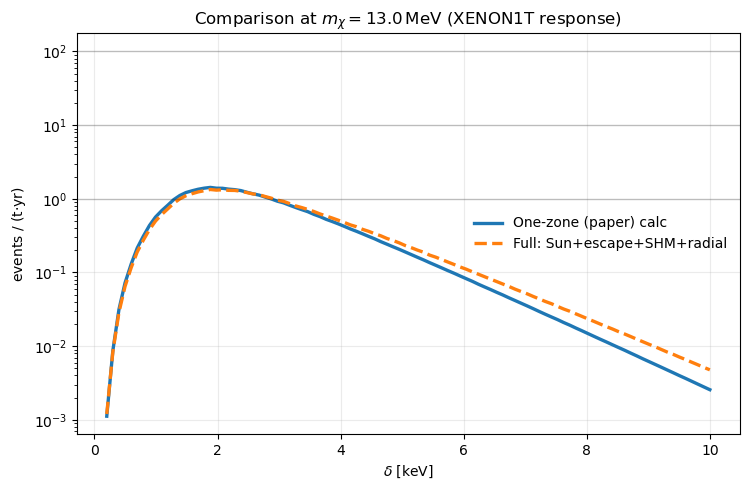

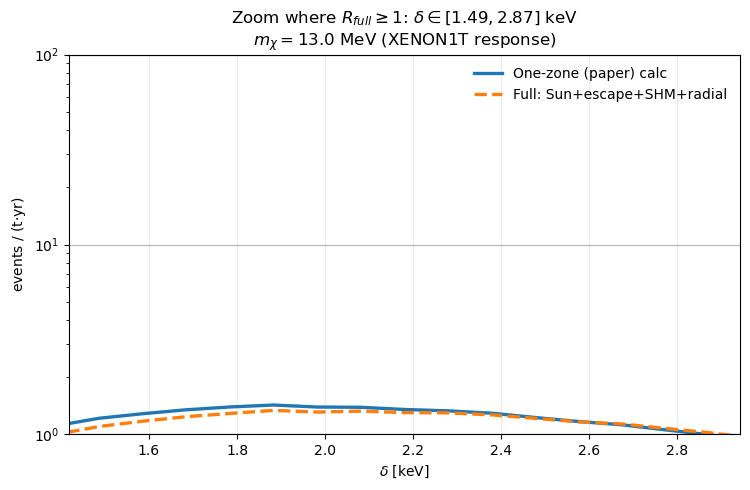

In [ ]:
import os, time, platform
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from concurrent.futures import ProcessPoolExecutor, as_completed

# ====================== Small helpers / numerics ======================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

# =================== Constants / geometry / detector ===================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30
SEC_PER_YR    = 365.25*24*3600.0

# Xenon
A_Xe_gmol     = 131.293
Zfree_Xe      = 26
N_A           = 6.022_140_76e23
NT_per_ton    = (N_A * Zfree_Xe / A_Xe_gmol) * 1.0e6

# Masses / units
m_e_keV       = 511.0
GEV2_TO_CM2   = 0.389379e-27
KEV_PER_GEV   = 1.0e6

# ====================== Robust CSV path handling (WSL/UNC) ======================
def resolve_wsl_path(p):
    """Translate a UNC WSL path to Linux form when running under a Linux/WSL kernel."""
    if os.name != "nt" and p.startswith(("\\\\wsl.localhost\\Ubuntu", "//wsl.localhost/Ubuntu")):
        p2 = p.replace("\\\\wsl.localhost\\Ubuntu", "").replace("//wsl.localhost/Ubuntu", "").replace("\\", "/")
        if not p2.startswith("/"):
            p2 = "/" + p2
        return p2
    return p

def load_efficiency_csv_any(csv_path):
    """Try UNC path, Linux-resolved path, then basename."""
    candidates = [csv_path, resolve_wsl_path(csv_path), os.path.basename(csv_path)]
    last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                arr = np.genfromtxt(p, delimiter=",", comments="#")
                if arr.ndim == 1:
                    arr = np.genfromtxt(p, delimiter=";", comments="#")
                    if arr.ndim == 1:
                        raise ValueError("CSV parse failed for both ',' and ';'")
                E   = np.asarray(arr[:,0], float)
                eps = np.asarray(arr[:,1], float)
                m   = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
                E, eps = E[m], _clip01(eps[m])
                idx = np.argsort(E); E, eps = E[idx], eps[idx]
                print(f"[ε] Loaded: {p}")
                return E, eps
        except Exception as e:
            last_err = e
    raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")

def make_eps_func_from_points(Epts, epspts, clamp_left_to_zero=True):
    logE = np.log(Epts)
    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), Epts[0]*1e-6))
        vals = np.interp(x, logE, epspts, left=epspts[0], right=epspts[-1])
        if clamp_left_to_zero:
            vals = np.where(np.asarray(EkeV, float) < Epts[0], 0.0, vals)
        return _clip01(vals)
    return eps_func

# ================ XENON1T resolution & smearing matrix =================
A_RES, B_RES = 0.313, 0.0017  # tweakable
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def build_smear_matrix(ER_true, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    if ER_rec is None: ER_rec = Etrue
    Erec = np.asarray(ER_rec, float)
    sig = sigma_res_keV(Etrue)[None, :] + 1e-30
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/sig)**2)/(np.sqrt(2*np.pi)*sig)
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*sig)))
        G    /= np.maximum(denom, 1e-12)
    dE = np.gradient(Etrue)
    return G * dE[None, :], Erec

# ===================== Common kinematics / sigma_e =====================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV*KEV_PER_GEV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def y_from_eps_line(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0, m0_GeV=0.1):
    m = np.asarray(mchi_GeV, float)
    eps = (c_eps*1e-4) * (m/m0_GeV) * (r/3.0)**2 * (alpha_D/0.5)**(-0.5)
    return (eps**2)*alpha_D/(r**4)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r=3.0, c_eps=1.0):
    m = np.asarray(mchi_GeV, float)
    me_GeV = m_e_keV*1e-6
    mu_GeV = (m*me_GeV)/(m+me_GeV)
    y      = y_from_eps_line(m, alpha_D=alpha_D, r=r, c_eps=c_eps)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_GeV**2)*y/(m**4)
    return sig_GeV2*GEV2_TO_CM2

# ======================= PAPER (one-zone) side ==========================
T_sun_keV     = 1.10
n_e_core      = 2.0e25
V_core_cm3    = 2.2e31
vesc_over_v0  = 7.0  # focusing fudge

def vmin2_for_Kstar(mchi_GeV, Kstar_keV, delta_keV):
    mchi_keV = mchi_GeV*KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)
    term     = (mchi_keV*Ksafe)/mu + delta_keV
    return (term*term)/(2.0*mchi_keV*Ksafe)

def I_MB(vmin2):
    a    = m_e_keV/(2.0*T_sun_keV)
    pref = np.sqrt(2.0*m_e_keV/(np.pi*T_sun_keV))
    return pref*np.exp(-a*vmin2)

def dphi_dKstar_solar_paper(mchi_GeV, delta_keV, Kgrid_keV, *, alpha_D, r, c_eps):
    n_inf   = rho0_GeVcm3/(mchi_GeV + _EPS)
    n_core  = n_inf*vesc_over_v0
    sig_e   = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    mchi_keV= mchi_GeV*KEV_PER_GEV
    mu      = mu_keV(mchi_GeV)
    pref    = C_LIGHT*n_e_core*n_core*sig_e*(mchi_keV/(2.0*mu*mu))
    vmin2   = vmin2_for_Kstar(mchi_GeV, Kgrid_keV, delta_keV)
    prod    = pref*I_MB(vmin2)
    geom    = V_core_cm3/(4.0*np.pi*AU_cm**2)
    return geom*prod

def vchi2_from_K(mchi_GeV, K_keV):
    return 2.0*K_keV/(mchi_GeV*KEV_PER_GEV + _EPS)

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV*KEV_PER_GEV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dsdER_electron(mchi_GeV, K_keV, *, alpha_D, r, c_eps):
    mu      = mu_keV(mchi_GeV)
    v2      = np.maximum(vchi2_from_K(mchi_GeV, K_keV), 1e-30)
    sig_e   = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r, c_eps=c_eps)
    return sig_e*(m_e_keV/(2.0*mu*mu*v2))

def total_events_paper(mchi_GeV, delta_keV, *, K_grid, ER_grid, G, eps_func, alpha_D, r, c_eps):
    dphi   = dphi_dKstar_solar_paper(mchi_GeV, delta_keV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)
    dsdER  = dsdER_electron(mchi_GeV, K_grid, alpha_D=alpha_D, r=r, c_eps=c_eps)
    out = np.zeros_like(ER_grid)
    Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER_grid)
    for i, Km in enumerate(Kmin):
        m = K_grid >= Km
        if np.any(m):
            out[i] = NT_per_ton * trapz(dphi[m]*dsdER[m], K_grid[m]) * SEC_PER_YR
    S_vis = eps_func(ER_grid) * (G @ out)
    return float(trapz(S_vis, ER_grid))

# =================== FULL (Sun+escape+SHM+radial) side ===================
# SHM in Sun frame
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms/c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u/(np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u < max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u < (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# solar profiles
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

n_e0, T0_keV = 6.0e25, 1.30
def shape_r(r_cm): x = r_cm/R_sun_cm; return (1.0 - x*x)**2
def n_e_of_r(r_cm): return n_e0*shape_r(r_cm)
def T_of_r(r_cm):   return T0_keV*(0.7 + 0.3*shape_r(r_cm))

def dGamma_dv_per_nsigma(r_cm, vchi, v_local, mchi_keV, mT_keV, delta_keV, qN=240, qsigma=10.0):
    if v_local <= 0.0 or vchi <= 0.0: return 0.0
    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)
    if v_local < (Kesc/mchi_keV): return 0.0
    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v_local*v_local - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in): return 0.0
    costh = np.clip(costh, -1.0, 1.0)
    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    integrand = (mchi_keV*v_local)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

def build_shared_cache(Nr, Nvinf):
    r  = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)
    ne_r  = n_e_of_r(r)
    vesc_r= vesc_of_r(r)
    return dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf, ne_r=ne_r, vesc_r=vesc_r)

def dphi_dKstar_earth(Kgrid_keV, mchi_GeV, delta_keV, *, cache, qN, alpha_D, r_ratio, c_eps):
    r, dr, ugrid, gpdf, ne_r, vesc_r = cache["r"], cache["dr"], cache["ugrid"], cache["gpdf"], cache["ne_r"], cache["vesc_r"]
    mchi_keV = mchi_GeV*1e6
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r_ratio, c_eps=c_eps)
    n_inf    = rho0_GeVcm3/(mchi_GeV + 1e-300)
    geom     = 1.0/(4.0*np.pi*AU_cm**2)
    out = np.zeros_like(Kgrid_keV, dtype=float)
    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri, ne, vesc in zip(r, ne_r, vesc_r):
            v_local = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v_local) or v_local <= vesc:
                continue
            dv_dK     = 1.0/(mchi_keV*v_local + 1e-300)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)
            Gamma_vals = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_e_keV, delta_keV, qN=qN)
                                   for vc in vchi_grid], dtype=float)
            avg = trapz(vchi_grid*gpdf * Gamma_vals, ugrid)
            shell_sum += (4.0*np.pi*ri*ri) * ne * sigma_e * avg * dv_dK * dr
        out[iK] = n_inf*C_LIGHT*geom*shell_sum
    return out

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid, K_grid, dphi_dK, *, alpha_D, r_ratio, c_eps):
    mu      = mu_keV(mchi_GeV)
    v2      = np.maximum(2.0*K_grid/(mchi_GeV*KEV_PER_GEV + _EPS), 1e-30)
    sig_e   = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r=r_ratio, c_eps=c_eps)
    dsdER   = sig_e*(m_e_keV/(2.0*mu*mu*v2))
    out = np.zeros_like(ER_grid)
    Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER_grid)
    for i, Km in enumerate(Kmin):
        m = K_grid >= Km
        if np.any(m):
            out[i] = NT_per_ton * trapz(dphi_dK[m]*dsdER[m], K_grid[m]) * SEC_PER_YR
    return out

def total_events_full(mchi_GeV, delta_keV, *, K_grid, ER_grid, G, eps_func, cache, qN, alpha_D, r_ratio, c_eps):
    dphi   = dphi_dKstar_earth(K_grid, mchi_GeV, delta_keV, cache=cache, qN=qN,
                               alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    dRdER  = dRdER_from_flux(mchi_GeV, delta_keV, ER_grid, K_grid, dphi,
                             alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    S_vis  = eps_func(ER_grid) * (G @ dRdER)
    return float(trapz(S_vis, ER_grid))

# ====================== Worker initializer (no closures) ======================
# Globals in workers:
_W_G = None
_W_EPTS = None
_W_EPSPTS = None
_W_CACHE = None
_W_KGRID = None
_W_ERGRID = None
_W_CONF = None

def _init_worker(G, Epts, epspts, cache, Kgrid, ERgrid, conf):
    global _W_G, _W_EPTS, _W_EPSPTS, _W_CACHE, _W_KGRID, _W_ERGRID, _W_CONF
    _W_G, _W_EPTS, _W_EPSPTS, _W_CACHE, _W_KGRID, _W_ERGRID, _W_CONF = G, Epts, epspts, cache, Kgrid, ERgrid, conf

def _eps_func_worker(EkeV):
    # build from points each call is cheap (log/points small); avoids pickling closures
    return make_eps_func_from_points(_W_EPTS, _W_EPSPTS, clamp_left_to_zero=True)(EkeV)

def _task_full_delta(idx_and_delta):
    i, dkeV = idx_and_delta
    val = total_events_full(_W_CONF["mchi_GeV"], dkeV,
                            K_grid=_W_KGRID, ER_grid=_W_ERGRID, G=_W_G, eps_func=_eps_func_worker,
                            cache=_W_CACHE, qN=_W_CONF["qN"],
                            alpha_D=_W_CONF["alpha_D"], r_ratio=_W_CONF["r_ratio"], c_eps=_W_CONF["c_eps"])
    return i, val

# =================================== Driver ====================================
if __name__ == "__main__":
    # ---------------------------- Knobs ----------------------------
    mchi_MeV_target = 13.0
    delta_grid_keV  = np.linspace(0.2, 10.0, 100)

    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"
    renorm_at_zero = False

    # Integration grids (shared)
    K_max_keV, NK   = 100.0, 3000
    ER_max, NER     = 30.0, 2001
    K_grid          = np.linspace(0.02, K_max_keV, NK)
    ER_grid         = np.linspace(0.02, ER_max, NER)

    # Physics
    alpha_D = 0.5
    r_ratio = 3.0

    # Full-flux resolution
    Nr, Nvinf, qN = 40, 128, 320

    # ----------------------- Precompute common ----------------------
    Epts, epspts = load_efficiency_csv_any(CSV_PATH)
    eps_func     = make_eps_func_from_points(Epts, epspts, clamp_left_to_zero=True)
    G, ER_rec    = build_smear_matrix(ER_grid, ER_grid, renorm_at_zero=renorm_at_zero)

    # Calibrate c_eps at (3.7 MeV, 3.5 keV) ON THE PAPER MODEL (then reuse)
    def calib_events_paper(c_eps_guess):
        return total_events_paper(3.7e-3, 3.5,
                                  K_grid=K_grid, ER_grid=ER_grid, G=G, eps_func=eps_func,
                                  alpha_D=alpha_D, r=r_ratio, c_eps=c_eps_guess)
    c_eps = 1.0
    base  = calib_events_paper(c_eps)
    if base <= 0: raise RuntimeError("Bad base events; check ε(E) CSV.")
    target = 60.0
    c_eps  = c_eps * (target/base)**0.25
    print(f"[calibration] c_eps = {c_eps:.5g}  (base={base:.2f} → target={target:.2f} events/t·yr)")

    mchi_GeV = mchi_MeV_target*1e-3

    # Shared cache for FULL curve
    cache = build_shared_cache(Nr, Nvinf)

    # ----------------------- Sweep δ: PAPER -------------------------
    t0 = time.time()
    events_paper = []
    for dkeV in delta_grid_keV:
        ev = total_events_paper(mchi_GeV, dkeV,
                                K_grid=K_grid, ER_grid=ER_grid, G=G, eps_func=eps_func,
                                alpha_D=alpha_D, r=r_ratio, c_eps=c_eps)
        events_paper.append(ev)
    events_paper = np.array(events_paper, float)
    t_paper = time.time() - t0

    # ------------------------ Sweep δ: FULL (parallel, robust) -------------------------
    NPROC = max(1, os.cpu_count() - 1)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")

    t0 = time.time()  # <-- start timing the FULL sweep properly
    events_full = np.zeros_like(delta_grid_keV, dtype=float)
    conf = dict(mchi_GeV=mchi_GeV, qN=qN, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

    if NPROC == 1:
        for i, d in enumerate(delta_grid_keV):
            events_full[i] = total_events_full(mchi_GeV, d,
                                               K_grid=K_grid, ER_grid=ER_grid, G=G, eps_func=eps_func,
                                               cache=cache, qN=qN,
                                               alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    else:
        with ProcessPoolExecutor(max_workers=NPROC,
                                 initializer=_init_worker,
                                 initargs=(G, Epts, epspts, cache, K_grid, ER_grid, conf)) as ex:
            futs = [ex.submit(_task_full_delta, (i, d)) for i, d in enumerate(delta_grid_keV)]
            done = 0; step = max(1, len(futs)//20)
            for f in as_completed(futs):
                i, val = f.result()
                events_full[i] = val
                done += 1
                if (done % step == 0) or (done == len(futs)):
                    print(f"\r[full] {done}/{len(futs)} points", end="", flush=True)
        print()

    t_full = time.time() - t0
    print(f"[timing] paper: {t_paper:.2f}s   full: {t_full:.2f}s   (NPROC={NPROC}, NK={NK}, Nr={Nr}, Nvinf={Nvinf}, qN={qN})")

    # ----------------------------- Plot 1: full Δ range ----------------------------
    plt.figure(figsize=(7.6,5.0))
    plt.plot(delta_grid_keV, events_paper, lw=2.4, label="One-zone (paper) calc")
    plt.plot(delta_grid_keV, events_full,  lw=2.4, ls="--", label="Full: Sun+escape+SHM+radial")
    for y in (1.0, 10.0, 100.0):
        plt.axhline(y, color="k", alpha=0.2, lw=1.0)
    plt.yscale("log")
    plt.xlabel(r"$\delta$ [keV]")
    plt.ylabel(r"events / (t$\cdot$yr)")
    plt.title(rf"Comparison at $m_\chi={mchi_MeV_target:.1f}\,$MeV (XENON1T response)")
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # ----------------------------- Plot 2: zoom where R_full ≥ 1 ---------------------
    threshold = 1.0
    mask_full = events_full >= threshold
    if np.any(mask_full):
        dsel = delta_grid_keV[mask_full]
        dmin, dmax = dsel.min(), dsel.max()
        pad = 0.05 * max(dmax - dmin, delta_grid_keV[1] - delta_grid_keV[0])
        xmin = max(delta_grid_keV[0], dmin - pad)
        xmax = min(delta_grid_keV[-1], dmax + pad)

        plt.figure(figsize=(7.6,5.0))
        plt.plot(delta_grid_keV, events_paper, lw=2.4, label="One-zone (paper) calc")
        plt.plot(delta_grid_keV, events_full,  lw=2.4, ls="--", label="Full: Sun+escape+SHM+radial")
        for y in (1.0, 10.0, 100.0):
            plt.axhline(y, color="k", alpha=0.2, lw=1.0)
        plt.yscale("log")
        plt.ylim(1, 100) 
        plt.xlim(xmin, xmax)  # <-- zoomed Δ-axis
        plt.xlabel(r"$\delta$ [keV]")
        plt.ylabel(r"events / (t$\cdot$yr)")
        plt.title("\n".join([
    rf"Zoom where $R_{{full}}\geq 1$: $\delta\in[{dmin:.2f},{dmax:.2f}]$ keV",
    rf"$m_\chi={mchi_MeV_target:.1f}$ MeV (XENON1T response)"
]))
        plt.grid(alpha=0.25)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()
    else:
        print("[zoom] No Δ points satisfy R_full ≥ 1 events/(t·yr); skipping zoomed plot.")

[ε] Loaded efficiency from: /home/dtinocov/University/UD_2025/Efficiency curve digitization.csv
[225/225] points


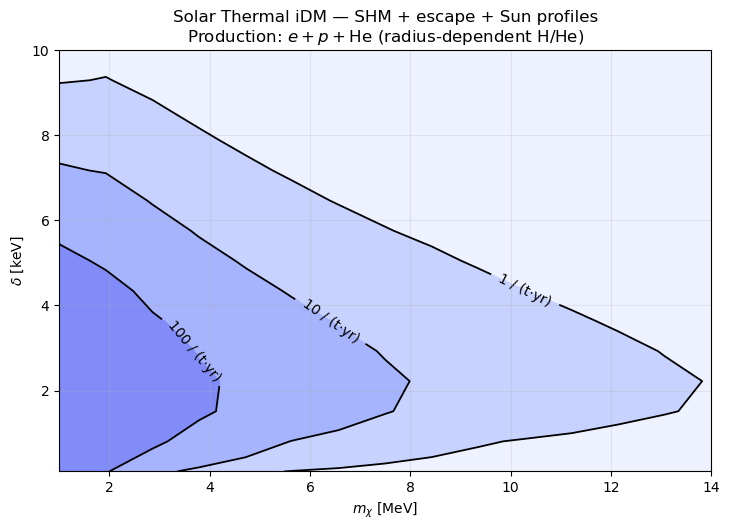

In [ ]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from concurrent.futures import ProcessPoolExecutor, as_completed

# ========================== Numerics / small helpers ==========================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

# ========================= Constants / geometry / detector ====================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30                  # local halo density
SEC_PER_YR    = 365.25*24*3600.0

# Halo (SHM) in the Sun frame
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    """ SHM speed PDF g(u) (not yet normalised), Sun frame, truncated at v_esc_gal. """
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=128):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# ============================== Solar profiles ===============================
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

# electron density/temperature shapes (kept simple)
n_e0   = 6.0e25           # cm^-3
T0_keV = 1.30             # keV
def shape_r(r_cm):
    x = r_cm/R_sun_cm
    return (1.0 - x*x)**2
def n_e_of_r(r_cm):  return n_e0 * shape_r(r_cm)
def T_of_r(r_cm):    return T0_keV*(0.7 + 0.3*shape_r(r_cm))

# --------- Radius-dependent composition model (no tables, but realistic) -----
# Photospheric (surface) fractions ~ Asplund-like, and core-enriched He.
X_surf, Z_const = 0.738, 0.013             # mass fractions at surface
X_core          = 0.34                      # core H mass fraction (He from 1-Z-X)
beta_mix        = 2.0                       # controls radial transition sharpness

def X_Y_of_r(r_cm, Xc=X_core, Xs=X_surf, Z=Z_const, beta=beta_mix):
    """
    Smoothly interpolate mass fractions X(r), Y(r)=1-Z-X(r) from core to surface:
      X(r) = X_surf + (X_core - X_surf) * w(r),  w = (1 - (r/R)^2)^beta
    """
    x = np.asarray(r_cm, float)/R_sun_cm
    w = np.maximum(0.0, 1.0 - x*x)**beta
    X = Xs + (Xc - Xs)*w
    Y = 1.0 - Z - X
    return X, Y

def frac_np_nHe_per_ne_of_r(r_cm):
    """Return number fractions relative to electrons: n_p/n_e, n_He/n_e at radius r."""
    X, Y = X_Y_of_r(r_cm)
    den  = X + 0.5*Y              # = n_e per unit baryon in H/He plasma
    Fp   = X/den                  # n_p/n_e
    FHe  = 0.25*Y/den             # n_He/n_e
    return Fp, FHe                # guarantees n_e = n_p + 2 n_He

# ============================= Masses & units ================================
m_e_keV   = 511.0
m_p_keV   = 938.2720813e3
m_He_keV  = 3.727379e6
m_e_GeV   = m_e_keV*1e-6
m_p_GeV   = m_p_keV*1e-6
m_He_GeV  = m_He_keV*1e-6

GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GeV = 1.0e6

# ======================= Thermal-line normalisation (paper) ==================
def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    ε = (c_eps × 1e-4) (mχ/0.1 GeV) ((mA'/mχ)/3)^2 (αD/0.5)^(-1/2)
    y = ε^2 α_D / r^4
    σ_e = 16 π α_em μ_e^2 y / mχ^4   (contact limit), in cm^2.
    """
    mchi_GeV = float(mchi_GeV)
    mu_e_GeV = (mchi_GeV*m_e_GeV)/(mchi_GeV+m_e_GeV)
    eps = (c_eps*1.0e-4)*(mchi_GeV/0.1)*((r_ratio)/3.0)**2*(alpha_D/0.5)**(-0.5)
    y   = (eps**2)*alpha_D/(r_ratio**4)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_e_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2*GEV2_TO_CM2

def sigma_target_from_sigma_e(mchi_GeV, sigma_e, mT_GeV, ZT):
    """Scale σ_e → σ_T = σ_e * (μ_T/μ_e)^2 * Z_T^2 in contact limit."""
    mu_e = (mchi_GeV*m_e_GeV)/(mchi_GeV+m_e_GeV)
    mu_T = (mchi_GeV*mT_GeV)/(mchi_GeV+mT_GeV)
    return sigma_e * (mu_T/mu_e)**2 * (ZT**2)

# ============ dGamma/dv per (n σ) with angular cap (q-integral) ============
def dGamma_dv_per_nsigma(r_cm, vchi, v_local, mchi_keV, mT_keV, delta_keV,
                         qN=240, qsigma=10.0):
    """ Per-target, per-σ_tot differential escape rate density at fixed local speed v_local. """
    if v_local <= 0.0 or vchi <= 0.0:
        return 0.0
    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)
    if v_local < (Kesc/mchi_keV):
        return 0.0
    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v_local*v_local - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in):
        return 0.0
    costh = np.clip(costh, -1.0, 1.0)
    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    integrand = (mchi_keV*v_local)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

# ====================== dΦ/dK* at Earth from Sun + SHM (e+p+He) =======================
def dphi_dKstar_earth(Kgrid_keV, mchi_GeV, delta_keV, *,
                      Nr=32, Nvinf=96, qN=240,
                      alpha_D=0.5, r_ratio=3.0, c_eps=1.11475,
                      cached=None):
    """ dΦ/dK_*^Earth; [cm^-2 s^-1 keV^-1], including e + p + He in production. """
    if cached and "r" in cached:
        r      = cached["r"];  dr = cached["dr"]
        ugrid  = cached["ugrid"]; gpdf = cached["gpdf"]
        ne_r   = cached["ne_r"]; np_r  = cached["np_r"]; nHe_r = cached["nHe_r"]
        vesc_r = cached["vesc_r"]
    else:
        r  = np.linspace(0.0, R_sun_cm, Nr)
        dr = r[1] - r[0] if Nr > 1 else R_sun_cm
        ugrid, gpdf = make_speed_pdf_grid(Nvinf)
        ne_r  = n_e_of_r(r)
        Fp, FHe = frac_np_nHe_per_ne_of_r(r)
        np_r  = Fp  * ne_r
        nHe_r = FHe * ne_r
        vesc_r= vesc_of_r(r)
        if cached is not None:
            cached.update(dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf,
                               ne_r=ne_r, np_r=np_r, nHe_r=nHe_r, vesc_r=vesc_r))

    mchi_keV = mchi_GeV * 1e6
    sig_e    = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    sig_p    = sigma_target_from_sigma_e(mchi_GeV, sig_e, m_p_GeV, 1)
    sig_He   = sigma_target_from_sigma_e(mchi_GeV, sig_e, m_He_GeV, 2)

    n_inf     = rho0_GeVcm3 / (mchi_GeV + 1e-300)  # cm^-3
    geom      = 1.0 / (4.0 * np.pi * AU_cm**2)
    out = np.zeros_like(Kgrid_keV, dtype=float)

    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri, ne, np_, nHe, vesc in zip(r, ne_r, np_r, nHe_r, vesc_r):
            v_local = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v_local) or v_local <= vesc:
                continue
            dv_dK     = 1.0 / (mchi_keV * v_local + 1e-300)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)

            # --- electrons
            G_e = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_e_keV,  delta_keV, qN=qN)
                            for vc in vchi_grid], dtype=float)
            # --- protons
            G_p = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_p_keV,  delta_keV, qN=qN)
                            for vc in vchi_grid], dtype=float)
            # --- helium nuclei
            G_He= np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_He_keV, delta_keV, qN=qN)
                            for vc in vchi_grid], dtype=float)

            weight = vchi_grid * gpdf
            avg_e  = trapz(weight * G_e,  ugrid)
            avg_p  = trapz(weight * G_p,  ugrid)
            avg_He = trapz(weight * G_He, ugrid)

            shell_sum += (4.0*np.pi*ri*ri) * (
                ne  * sig_e  * avg_e +
                np_ * sig_p  * avg_p +
                nHe * sig_He * avg_He
            ) * dv_dK * dr

        out[iK] = n_inf * C_LIGHT * geom * shell_sum

    return out

# =================== Detector kernel & event spectrum dR/dER ==================
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def dsdER_electron(mchi_GeV, K_keV, *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    v2       = np.maximum(2.0*K_keV/(mchi_keV + _EPS), 1e-30)
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    return sigma_e * (m_e_keV/(2.0*mu*mu*v2))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV, K_grid_keV, dphi_dK_keV,
                    *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0,
                    NT_per_ton = (6.022_140_76e23 * 26 / 131.293) * 1.0e6):
    out = np.zeros_like(ER_grid_keV, dtype=float)
    dsdER = dsdER_electron(mchi_GeV, K_grid_keV, c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid_keV >= Kmin
        if not np.any(m): 
            continue
        integ = trapz(dphi_dK_keV[m]*dsdER[m], K_grid_keV[m])   # s^-1 per target
        out[i] = NT_per_ton * integ * SEC_PER_YR
    return out

# =================== XENON1T resolution + efficiency (CSV) ===================
A_RES = 0.313
B_RES = 0.0017
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def load_efficiency_csv(csv_path):
    try:
        arr = np.genfromtxt(csv_path, delimiter=",", comments="#")
        if arr.ndim == 1: raise ValueError
    except Exception:
        arr = np.genfromtxt(csv_path, delimiter=";", comments="#")
        if arr.ndim == 1: raise
    E = np.asarray(arr[:,0], float); eps = np.asarray(arr[:,1], float)
    m = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
    E, eps = E[m], _clip01(eps[m])
    idx = np.argsort(E); E, eps = E[idx], eps[idx]
    return E, eps

def build_efficiency_from_csv(csv_path):
    candidates = [csv_path]
    if csv_path.startswith("\\\\wsl.localhost\\Ubuntu\\"):
        candidates.append(csv_path.replace("\\\\wsl.localhost\\Ubuntu", "").replace("\\", "/"))
    candidates.append(os.path.basename(csv_path))
    last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                E, eps = load_efficiency_csv(p)
                print(f"[ε] Loaded efficiency from: {p}")
                break
        except Exception as e:
            last_err = e
    else:
        raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")
    logE = np.log(E)
    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), E[0]*1e-6))
        vals = np.interp(x, logE, eps, left=eps[0], right=eps[-1])
        return _clip01(vals)
    return eps_func, (E, eps)

def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec = np.asarray(ER_rec, float)
    sig = sigma_res_keV(Etrue)[None, :]
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/np.maximum(sig,1e-12))**2)/(np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)
    dE      = np.gradient(Etrue)
    S_smear = (G*(S[None,:]*dE[None,:])).sum(axis=1)
    S_vis   = eps_func(Erec)*S_smear
    return Erec, S_vis, S_smear

# ========================== Map builder (events / t·yr) ======================
def total_events_tyr(mchi_GeV, delta_keV, eps_func, *,
                     K_grid_keV, ER_grid_keV,
                     Nr=32, Nvinf=96, qN=240,
                     alpha_D=0.5, r_ratio=3.0, c_eps=1.11475,
                     cached=None):
    dphi_dK = dphi_dKstar_earth(K_grid_keV, mchi_GeV, delta_keV,
                                Nr=Nr, Nvinf=Nvinf, qN=qN,
                                alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps,
                                cached=cached)
    dRdER_true = dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV,
                                 K_grid_keV, dphi_dK,
                                 c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    ER_rec, dRdER_vis, _ = smear_and_apply_eff(ER_grid_keV, dRdER_true, eps_func, ER_grid_keV)
    return float(trapz(dRdER_vis, ER_rec))

# ========================== Parallel infrastructure ==========================
_CACHE = None
_KGRID = None
_ERGRID = None
_EPS_FUNC = None
_CONFIG = None

def _init_worker(cache, Kgrid, ERgrid, Epts, epspts, config):
    """Initializer: runs once per process."""
    import numpy as _np
    global _CACHE, _KGRID, _ERGRID, _EPS_FUNC, _CONFIG
    _CACHE = cache
    _KGRID = Kgrid
    _ERGRID = ERgrid
    _CONFIG = config
    logE = _np.log(Epts)
    def eps_func_local(EkeV):
        x = _np.log(_np.maximum(_np.asarray(EkeV, float), Epts[0]*1e-6))
        vals = _np.interp(x, logE, epspts, left=epspts[0], right=epspts[-1])
        return _np.clip(vals, 0.0, 1.0)
    _EPS_FUNC = eps_func_local

def _task_point(idx_pair_m_d):
    """Worker: compute total events at one (mχ, δ) point."""
    (ix, iy, m_GeV, d_keV) = idx_pair_m_d
    Rval = total_events_tyr(m_GeV, d_keV, _EPS_FUNC,
                            K_grid_keV=_KGRID, ER_grid_keV=_ERGRID,
                            Nr=_CONFIG["Nr"], Nvinf=_CONFIG["Nvinf"], qN=_CONFIG["qN"],
                            alpha_D=_CONFIG["alpha_D"], r_ratio=_CONFIG["r_ratio"], c_eps=_CONFIG["c_eps"],
                            cached=_CACHE)
    return ix, iy, Rval

def build_shared_cache(Nr, Nvinf):
    """Precompute Sun/SHM arrays once in the parent; copy-on-fork to workers."""
    r  = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)
    ne_r  = n_e_of_r(r)
    Fp, FHe = frac_np_nHe_per_ne_of_r(r)
    np_r  = Fp  * ne_r
    nHe_r = FHe * ne_r
    vesc_r= vesc_of_r(r)
    return dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf,
                ne_r=ne_r, np_r=np_r, nHe_r=nHe_r, vesc_r=vesc_r)

# =================================== Main ====================================
if __name__ == "__main__":
    # --- model constants (kept fixed across the scan) ---
    c_eps   = 1.11475
    alpha_D = 0.5
    r_ratio = 3.0

    # --- efficiency CSV (digitized XENON1T total ε) ---
    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"
    eps_func, (Epts, epspts) = build_efficiency_from_csv(CSV_PATH)

    # --- grids ---
    K_max_keV   = 60.0
    NK          = 1000
    K_grid_keV  = np.linspace(0.02, K_max_keV, NK)
    ER_grid_keV = np.linspace(0.02, 30.0, 2001)

    # parameter-space grid
    mchi_vals_MeV  = np.linspace(1.0, 14.0, 15)     # x-axis
    delta_vals_keV = np.linspace(0.1, 10.0, 15)     # y-axis

    # physics / integration knobs
    Nr, Nvinf, qN = 40, 128, 320

    # --- shared caches to reuse SHM + solar profiles ---
    shared_cache = build_shared_cache(Nr, Nvinf)

    # --- parallel config ---
    NPROC = max(1, os.cpu_count() - 1)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")

    R = np.zeros((delta_vals_keV.size, mchi_vals_MeV.size), dtype=float)

    if NPROC == 1:
        # Sequential fallback
        for ix, m_MeV in enumerate(mchi_vals_MeV):
            m_GeV = m_MeV*1e-3
            for iy, d_keV in enumerate(delta_vals_keV):
                R[iy, ix] = total_events_tyr(m_GeV, d_keV, eps_func,
                                             K_grid_keV=K_grid_keV, ER_grid_keV=ER_grid_keV,
                                             Nr=Nr, Nvinf=Nvinf, qN=qN,
                                             alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps,
                                             cached=shared_cache)
    else:
        # Build task list
        tasks = []
        for ix, m_MeV in enumerate(mchi_vals_MeV):
            m_GeV = m_MeV*1e-3
            for iy, d_keV in enumerate(delta_vals_keV):
                tasks.append((ix, iy, m_GeV, d_keV))

        config = dict(Nr=Nr, Nvinf=Nvinf, qN=qN,
                      alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

        done = 0
        step = max(1, len(tasks)//40)

        with ProcessPoolExecutor(max_workers=NPROC,
                                 initializer=_init_worker,
                                 initargs=(shared_cache, K_grid_keV, ER_grid_keV, Epts, epspts, config)) as ex:
            futures = [ex.submit(_task_point, t) for t in tasks]
            for fut in as_completed(futures):
                ix, iy, val = fut.result()
                R[iy, ix] = val
                done += 1
                if (done % step == 0) or (done == len(tasks)):
                    print(f"\r[{done}/{len(tasks)}] points", end="", flush=True)
        print()

    # --- plot: parameter space including e+p+He in solar production ---
    LEVELS = [1.0, 10.0, 100.0]   # events per t·yr
    fig, ax = plt.subplots(figsize=(7.4, 5.4))

    cf = ax.contourf(mchi_vals_MeV, delta_vals_keV, R,
                     levels=[0.0] + LEVELS + [R.max()*1.01],
                     colors=["#eef2ff", "#c7d2fe", "#a5b4fc", "#818cf8"])
    cs = ax.contour(mchi_vals_MeV, delta_vals_keV, R,
                    levels=LEVELS, colors="k", linewidths=1.3)
    ax.clabel(cs, fmt=lambda v: fr"{int(v):d} / (t·yr)", inline=True, fontsize=10)

    ax.set_xlabel(r"$m_\chi$ [MeV]")
    ax.set_ylabel(r"$\delta$ [keV]")
    ax.set_xlim(mchi_vals_MeV[0], mchi_vals_MeV[-1])
    ax.set_ylim(delta_vals_keV[0], delta_vals_keV[-1])
    ax.set_title("Solar Thermal iDM — SHM + escape + Sun profiles\n"
                 "Production: $e + p + \\mathrm{He}$ (radius-dependent H/He)")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

[ε] Loaded: /home/dtinocov/University/UD_2025/Efficiency curve digitization.csv
[calibration] c_eps = 1.1168  (base=38.57 → target=60.00 events/t·yr)
[full e] 100/100 points
[full e+p+He] 100/100 points
[timing] one-zone: 2.13s | full(e): 3879.08s | full(e+p+He): 16016.53s  (NPROC=15)


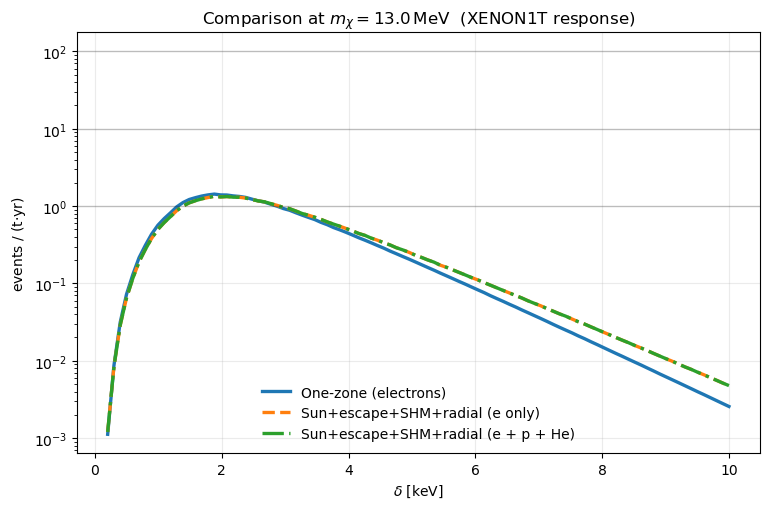

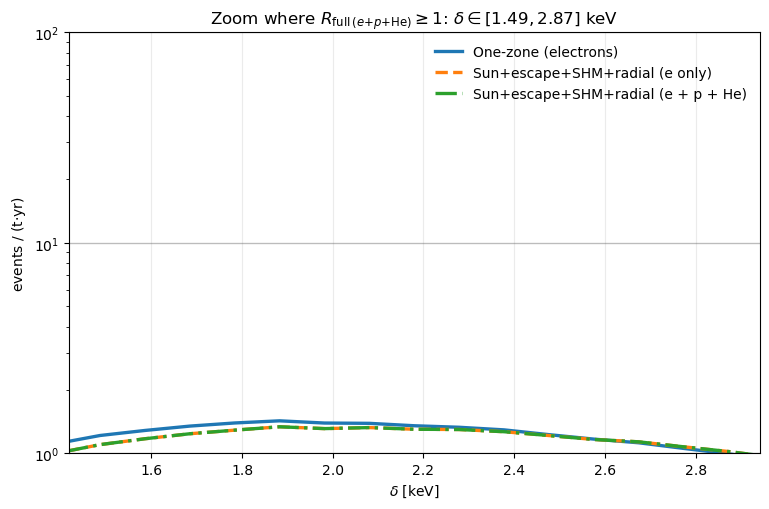

In [ ]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from concurrent.futures import ProcessPoolExecutor, as_completed

# ========================== Numerics / small helpers ==========================
trapz = np.trapz
_EPS  = 1e-300
def _clip01(x): return np.clip(x, 0.0, 1.0)

# ========================= Constants / geometry / detector ====================
alpha_em      = 1/137.035999084
C_LIGHT       = 2.997_924_58e10       # cm/s
AU_cm         = 1.495978707e13        # cm
R_sun_cm      = 6.957e10              # cm
rho0_GeVcm3   = 0.30                  # local halo density
SEC_PER_YR    = 365.25*24*3600.0

# Xenon (targets for detection)
A_Xe_gmol     = 131.293
Zfree_Xe      = 26
N_A           = 6.022_140_76e23
NT_per_ton    = (N_A * Zfree_Xe / A_Xe_gmol) * 1.0e6

# ============================== Halo (SHM, Sun frame) =========================
c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
v0_kms, v_sun_kms, v_esc_gal_kms = 220.0, 232.0, 544.0
v0, v_sun, v_esc_gal = map(kms_to_c, [v0_kms, v_sun_kms, v_esc_gal_kms])

def speed_pdf_raw(u):
    """SHM speed PDF g(u) (unnormalised), Sun frame, truncated at v_esc_gal."""
    u = np.asarray(u, float)
    out = np.zeros_like(u)
    a = (u - v_sun)**2/(v0*v0)
    b = (u + v_sun)**2/(v0*v0)
    c = (v_esc_gal*v_esc_gal)/(v0*v0)
    pref = u / (np.sqrt(np.pi)*v0*v_sun + _EPS)
    m1 = (u >= 0) & (u <  max(v_esc_gal - v_sun, 0.0))
    m2 = (u >= max(v_esc_gal - v_sun, 0.0)) & (u <  (v_esc_gal + v_sun))
    out[m1] = pref[m1]*(np.exp(-a[m1]) - np.exp(-b[m1]))
    out[m2] = pref[m2]*(np.exp(-a[m2]) - np.exp(-c))
    return out

def make_speed_pdf_grid(Nu=128):
    umax  = v_esc_gal + v_sun
    ugrid = np.linspace(0.0, umax, Nu)
    g_raw = speed_pdf_raw(ugrid)
    norm  = trapz(g_raw, ugrid)
    g_pdf = g_raw/norm if norm > 0 else g_raw
    return ugrid, g_pdf

# ============================== Solar profiles ===============================
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
def vesc_of_r(r_cm):
    x = r_cm/R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x*x) + v_esc_surf_kms*(x*x)
    return kms_to_c(v_kms)

# Electron density and temperature (toy radial shapes)
n_e0   = 6.0e25           # cm^-3 (central)
T0_keV = 1.30             # keV (central)
def shape_r(r_cm):
    x = r_cm/R_sun_cm
    return (1.0 - x*x)**2
def n_e_of_r(r_cm):  return n_e0 * shape_r(r_cm)
def T_of_r(r_cm):    return T0_keV*(0.7 + 0.3*shape_r(r_cm))

# ---------- Composition model WITHOUT tables (smooth core→surface evolution) ----------
X_core,  Y_core  = 0.34, 0.64
X_surf,  Y_surf  = 0.74, 0.24
Z_const          = 0.02
_comp_p = 1.6
def X_of_r(r_cm):
    s = shape_r(r_cm)**_comp_p
    return X_surf - (X_surf - X_core)*s
def Y_of_r(r_cm):
    s = shape_r(r_cm)**_comp_p
    return Y_surf + (Y_core - Y_surf)*s

def number_fractions_from_mass(X, Y, Z=Z_const):
    denom = (X + 0.5*Y) + 1e-30
    f_p_by_ne  = X/denom
    f_He_by_ne = (0.25*Y)/denom
    return f_p_by_ne, f_He_by_ne

# ============================= Masses & units ================================
m_e_keV   = 511.0
m_p_keV   = 938.2720813e3
m_He_keV  = 3.727379e6
m_e_GeV   = m_e_keV*1e-6
m_p_GeV   = m_p_keV*1e-6
m_He_GeV  = m_He_keV*1e-6

GEV2_TO_CM2 = 0.389379e-27
KEV_PER_GeV = 1.0e6

# ======================= XENON1T resolution + efficiency =====================
A_RES = 0.313
B_RES = 0.0017
def sigma_res_keV(E_keV, a=A_RES, b=B_RES):
    E = np.maximum(np.asarray(E_keV, float), 0.0)
    return a*np.sqrt(E) + b*E

def resolve_wsl_path(p):
    if os.name != "nt" and p.startswith(("\\\\wsl.localhost\\Ubuntu", "//wsl.localhost/Ubuntu")):
        p2 = p.replace("\\\\wsl.localhost\\Ubuntu", "").replace("//wsl.localhost/Ubuntu", "").replace("\\", "/")
        if not p2.startswith("/"):
            p2 = "/" + p2
        return p2
    return p

def load_efficiency_csv_any(csv_path):
    candidates = [csv_path, resolve_wsl_path(csv_path), os.path.basename(csv_path)]
    last_err = None
    for p in candidates:
        try:
            if os.path.exists(p):
                arr = np.genfromtxt(p, delimiter=",", comments="#")
                if arr.ndim == 1:
                    arr = np.genfromtxt(p, delimiter=";", comments="#")
                    if arr.ndim == 1:
                        raise ValueError("CSV parse failed for both ',' and ';'")
                E   = np.asarray(arr[:,0], float)
                eps = np.asarray(arr[:,1], float)
                m   = np.isfinite(E) & np.isfinite(eps) & (E > 0.0)
                E, eps = E[m], _clip01(eps[m])
                idx = np.argsort(E); E, eps = E[idx], eps[idx]
                print(f"[ε] Loaded: {p}")
                return E, eps
        except Exception as e:
            last_err = e
    raise FileNotFoundError(f"Could not load efficiency CSV. Last error: {last_err}")

def make_eps_func_from_points(Epts, epspts, clamp_left_to_zero=True):
    logE = np.log(Epts)
    def eps_func(EkeV):
        x = np.log(np.maximum(np.asarray(EkeV, float), Epts[0]*1e-6))
        vals = np.interp(x, logE, epspts, left=epspts[0], right=epspts[-1])
        if clamp_left_to_zero:
            vals = np.where(np.asarray(EkeV, float) < Epts[0], 0.0, vals)
        return _clip01(vals)
    return eps_func

def build_smear_matrix(ER_true, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    if ER_rec is None: ER_rec = Etrue
    Erec = np.asarray(ER_rec, float)
    sig = sigma_res_keV(Etrue)[None, :] + 1e-30
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/sig)**2)/(np.sqrt(2*np.pi)*sig)
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*sig)))
        G    /= np.maximum(denom, 1e-12)
    dE = np.gradient(Etrue)
    return G * dE[None, :], Erec

# ======================= Microphysics: σ_e and scaling to baryons =============
def mu_keV(mchi_GeV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    return (mchi_keV*m_e_keV)/(mchi_keV + m_e_keV)

def sigma_e_contact(mchi_GeV, *, alpha_D=0.5, r_ratio=3.0, c_eps=1.11475):
    """
    ε = (c_eps × 1e-4) * (mχ/0.1 GeV) * ((mA'/mχ)/3)^2 * (αD/0.5)^(-1/2)
    y = ε^2 α_D / r^4
    σ_e = 16 π α_em μ_e^2 y / mχ^4   (contact limit), in cm^2.
    """
    mchi_GeV = float(mchi_GeV)
    mu_e_GeV = (mchi_GeV*m_e_GeV)/(mchi_GeV+m_e_GeV)
    eps = (c_eps*1.0e-4)*(mchi_GeV/0.1)*((r_ratio)/3.0)**2*(alpha_D/0.5)**(-0.5)
    y   = (eps**2)*alpha_D/(r_ratio**4)
    sig_GeV2 = 16.0*np.pi*alpha_em*(mu_e_GeV**2)*y/(mchi_GeV**4)
    return sig_GeV2*GEV2_TO_CM2

def sigma_target_from_sigma_e(mchi_GeV, sigma_e, mT_GeV, ZT):
    """Scale σ_e → σ_T = σ_e * (μ_T/μ_e)^2 * Z_T^2 in contact limit."""
    mu_e = (mchi_GeV*m_e_GeV)/(mchi_GeV+m_e_GeV)
    mu_T = (mchi_GeV*mT_GeV)/(mchi_GeV+mT_GeV)
    return sigma_e * (mu_T/mu_e)**2 * (ZT**2)

# ============ dΓ/dv per (n σ) with angular cap (ANPPR-like q-integral) ============
def dGamma_dv_per_nsigma(r_cm, vchi, v_local, mchi_keV, mT_keV, delta_keV,
                         qN=240, qsigma=10.0):
    """Per-target, per-σ_tot differential escape rate density at fixed local speed v_local."""
    if v_local <= 0.0 or vchi <= 0.0:
        return 0.0
    T_keV = T_of_r(r_cm)
    p0    = np.sqrt(2.0*mT_keV*T_keV)      # keV
    k     = mchi_keV*vchi                  # keV
    Kesc  = mchi_keV*vesc_of_r(r_cm)       # keV
    mu    = mT_keV/(mchi_keV + _EPS)
    mu_p  = 0.5*(1.0 + mu)
    if v_local < (Kesc/mchi_keV):
        return 0.0
    qmin = max(0.0, Kesc - k) + 1e-12
    qmax = max(k + Kesc, 5.0*p0) + qsigma*p0
    q    = np.linspace(qmin, qmax, int(qN))
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (mchi_keV*(v_local*v_local - vchi*vchi) - (q*q)/mchi_keV)/(2.0*vchi*q + _EPS)
    m_in = (costh >= -1.0) & (costh <= 1.0)
    if not np.any(m_in):
        return 0.0
    costh = np.clip(costh, -1.0, 1.0)
    A = (mu_p*q + (mT_keV*delta_keV)/(q + _EPS) + mu*k*costh)/(p0 + _EPS)
    integrand = (mchi_keV*v_local)/(vchi*(p0**2 + _EPS)) * np.exp(-A*A)
    val = trapz(integrand[m_in], q[m_in])
    return float(val) if (np.isfinite(val) and val > 0.0) else 0.0

# ====================== dΦ/dK* at Earth (two variants) =======================
def _common_cache(Nr, Nvinf, want_baryons=False):
    """Make (or extend) a cache with solar/SHM grids and, if requested, n_p and n_He."""
    r = np.linspace(0.0, R_sun_cm, Nr)
    dr = r[1] - r[0] if Nr > 1 else R_sun_cm
    ugrid, gpdf = make_speed_pdf_grid(Nvinf)
    ne_r   = n_e_of_r(r)
    vesc_r = vesc_of_r(r)
    out = dict(r=r, dr=dr, ugrid=ugrid, gpdf=gpdf, ne_r=ne_r, vesc_r=vesc_r)
    if want_baryons:
        Xr, Yr = X_of_r(r), Y_of_r(r)
        fp, fHe = number_fractions_from_mass(Xr, Yr)
        out["np_r"]  = fp  * ne_r
        out["nHe_r"] = fHe * ne_r
    return out

def dphi_dK_earth_e_only(Kgrid_keV, mchi_GeV, delta_keV, *, cache, qN, alpha_D, r_ratio, c_eps):
    r, dr, ugrid, gpdf = cache["r"], cache["dr"], cache["ugrid"], cache["gpdf"]
    ne_r, vesc_r       = cache["ne_r"], cache["vesc_r"]
    mchi_keV = mchi_GeV*1e6
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    n_inf    = rho0_GeVcm3/(mchi_GeV + 1e-300)
    geom     = 1.0/(4.0*np.pi*AU_cm**2)
    out = np.zeros_like(Kgrid_keV, dtype=float)

    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri, ne, vesc in zip(r, ne_r, vesc_r):
            v_local = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v_local) or v_local <= vesc: continue
            dv_dK     = 1.0/(mchi_keV*v_local + 1e-300)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)
            G_e = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_e_keV, delta_keV, qN=qN)
                            for vc in vchi_grid], dtype=float)
            avg = trapz(vchi_grid*gpdf * G_e, ugrid)
            shell_sum += (4.0*np.pi*ri*ri) * ne * sigma_e * avg * dv_dK * dr
        out[iK] = n_inf*C_LIGHT*geom*shell_sum
    return out

def dphi_dK_earth_e_p_He(Kgrid_keV, mchi_GeV, delta_keV, *, cache, qN, alpha_D, r_ratio, c_eps):
    r, dr, ugrid, gpdf = cache["r"], cache["dr"], cache["ugrid"], cache["gpdf"]
    ne_r, vesc_r       = cache["ne_r"], cache["vesc_r"]
    np_r, nHe_r        = cache["nHe_r"], cache["np_r"]  # (we'll access by key explicitly below to avoid swap)

    # Correct order (explicit):
    np_r  = cache["np_r"]
    nHe_r = cache["nHe_r"]

    mchi_keV = mchi_GeV*1e6
    sig_e    = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    sig_p    = sigma_target_from_sigma_e(mchi_GeV, sig_e, m_p_GeV, 1)
    sig_He   = sigma_target_from_sigma_e(mchi_GeV, sig_e, m_He_GeV, 2)

    n_inf    = rho0_GeVcm3/(mchi_GeV + 1e-300)
    geom     = 1.0/(4.0*np.pi*AU_cm**2)
    out = np.zeros_like(Kgrid_keV, dtype=float)

    for iK, K in enumerate(Kgrid_keV):
        shell_sum = 0.0
        for ri, ne, np_, nHe, vesc in zip(r, ne_r, np_r, nHe_r, vesc_r):
            v_local = np.sqrt(vesc*vesc + 2.0*K/(mchi_keV + 1e-300))
            if not np.isfinite(v_local) or v_local <= vesc: continue
            dv_dK     = 1.0/(mchi_keV*v_local + 1e-300)
            vchi_grid = np.sqrt(ugrid*ugrid + vesc*vesc)

            G_e  = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_e_keV,  delta_keV, qN=qN) for vc in vchi_grid], float)
            G_p  = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_p_keV,  delta_keV, qN=qN) for vc in vchi_grid], float)
            G_He = np.array([dGamma_dv_per_nsigma(ri, vc, v_local, mchi_keV, m_He_keV, delta_keV, qN=qN) for vc in vchi_grid], float)

            w = vchi_grid*gpdf
            avg_e  = trapz(w*G_e,  ugrid)
            avg_p  = trapz(w*G_p,  ugrid)
            avg_He = trapz(w*G_He, ugrid)

            shell_sum += (4.0*np.pi*ri*ri) * (ne*sig_e*avg_e + np_*sig_p*avg_p + nHe*sig_He*avg_He) * dv_dK * dr

        out[iK] = n_inf*C_LIGHT*geom*shell_sum
    return out

# =================== Detector kernel & event spectrum dR/dER ==================
def dsdER_electron(mchi_GeV, K_keV, *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    v2       = np.maximum(2.0*K_keV/(mchi_keV + _EPS), 1e-30)
    sigma_e  = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    return sigma_e * (m_e_keV/(2.0*mu*mu*v2))

def Kmin_for_ER(mchi_GeV, delta_keV, ER_keV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    ER       = np.asarray(ER_keV, float)
    ERs      = np.maximum(ER, 1e-12)
    vmin     = np.abs((m_e_keV/mu)*ERs - delta_keV)/np.sqrt(2.0*m_e_keV*ERs)
    return 0.5*mchi_keV*(vmin*vmin)

def dRdER_from_flux(mchi_GeV, delta_keV, ER_grid_keV, K_grid_keV, dphi_dK_keV,
                    *, c_eps=1.11475, alpha_D=0.5, r_ratio=3.0,
                    NT_per_ton = NT_per_ton):
    out = np.zeros_like(ER_grid_keV, dtype=float)
    dsdER = dsdER_electron(mchi_GeV, K_grid_keV, c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    for i, ER in enumerate(ER_grid_keV):
        Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER)
        m    = K_grid_keV >= Kmin
        if not np.any(m): 
            continue
        integ = trapz(dphi_dK_keV[m]*dsdER[m], K_grid_keV[m])   # s^-1 per target
        out[i] = NT_per_ton * integ * SEC_PER_YR
    return out

def smear_and_apply_eff(ER_true, S_true, eps_func, ER_rec=None, *, renorm_at_zero=False):
    Etrue = np.asarray(ER_true, float)
    S     = np.asarray(S_true, float)
    if ER_rec is None:
        ER_rec = Etrue.copy()
    Erec = np.asarray(ER_rec, float)
    sig = sigma_res_keV(Etrue)[None, :]
    Et  = Etrue[None, :]
    Er  = Erec[:, None]
    G   = np.exp(-0.5*((Er-Et)/np.maximum(sig,1e-12))**2)/(np.sqrt(2*np.pi)*np.maximum(sig,1e-12))
    if renorm_at_zero:
        denom = 0.5*(1.0 + erf(Et/(np.sqrt(2.0)*np.maximum(sig,1e-12))))
        G    /= np.maximum(denom, 1e-12)
    dE      = np.gradient(Etrue)
    S_smear = (G*(S[None,:]*dE[None,:])).sum(axis=1)
    S_vis   = eps_func(Erec)*S_smear
    return Erec, S_vis, S_smear

# ======================= One-zone (“paper”) electron-only =====================
T_sun_keV   = 1.10
n_e_core    = 2.0e25
V_core_cm3  = 2.2e31
vesc_over_v0= 7.0

def vmin2_for_Kstar(mchi_GeV, Kstar_keV, delta_keV):
    mchi_keV = mchi_GeV*KEV_PER_GeV
    mu       = mu_keV(mchi_GeV)
    Ksafe    = np.maximum(Kstar_keV, 1e-300)
    term     = (mchi_keV*Ksafe)/mu + delta_keV
    return (term*term)/(2.0*mchi_keV*Ksafe)

def I_MB(vmin2):
    a    = m_e_keV/(2.0*T_sun_keV)
    pref = np.sqrt(2.0*m_e_keV/(np.pi*T_sun_keV))
    return pref*np.exp(-a*vmin2)

def dphi_dKstar_solar_paper(mchi_GeV, delta_keV, Kgrid_keV, *, alpha_D, r_ratio, c_eps):
    n_inf   = rho0_GeVcm3/(mchi_GeV + _EPS)
    n_core  = n_inf*vesc_over_v0
    sig_e   = sigma_e_contact(mchi_GeV, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    mchi_keV= mchi_GeV*KEV_PER_GeV
    mu      = mu_keV(mchi_GeV)
    pref    = C_LIGHT*n_e_core*n_core*sig_e*(mchi_keV/(2.0*mu*mu))
    vmin2   = vmin2_for_Kstar(mchi_GeV, Kgrid_keV, delta_keV)
    prod    = pref*I_MB(vmin2)
    geom    = V_core_cm3/(4.0*np.pi*AU_cm**2)
    return geom*prod

def total_events_paper(mchi_GeV, delta_keV, *, K_grid, ER_grid, G, eps_func, alpha_D, r_ratio, c_eps):
    dphi   = dphi_dKstar_solar_paper(mchi_GeV, delta_keV, K_grid, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
    dsdER  = dsdER_electron(mchi_GeV, K_grid, c_eps=c_eps, alpha_D=alpha_D, r_ratio=r_ratio)
    out = np.zeros_like(ER_grid)
    Kmin = Kmin_for_ER(mchi_GeV, delta_keV, ER_grid)
    for i, Km in enumerate(Kmin):
        m = K_grid >= Km
        if np.any(m):
            out[i] = NT_per_ton * trapz(dphi[m]*dsdER[m], K_grid[m]) * SEC_PER_YR
    S_vis = eps_func(ER_grid) * (G @ out)
    return float(trapz(S_vis, ER_grid))

# =============================== Worker globals ===============================
_W_EPTS = None
_W_EPSPTS = None
_W_K = None
_W_ER = None
_W_CACHE_E = None
_W_CACHE_epHe = None
_W_CONF = None

def _init_workers(epts, epspts, K_grid, ER_grid, cache_e, cache_epHe, conf):
    global _W_EPTS, _W_EPSPTS, _W_K, _W_ER, _W_CACHE_E, _W_CACHE_epHe, _W_CONF
    _W_EPTS, _W_EPSPTS = epts, epspts
    _W_K, _W_ER = K_grid, ER_grid
    _W_CACHE_E, _W_CACHE_epHe = cache_e, cache_epHe
    _W_CONF = conf

def _events_full_e_task(i, dkeV):
    eps_func = make_eps_func_from_points(_W_EPTS, _W_EPSPTS, clamp_left_to_zero=True)
    mchi = _W_CONF["mchi_GeV"]; qN=_W_CONF["qN"]; a=_W_CONF["alpha_D"]; r=_W_CONF["r_ratio"]; c=_W_CONF["c_eps"]
    dphi  = dphi_dK_earth_e_only(_W_K, mchi, dkeV, cache=_W_CACHE_E, qN=qN, alpha_D=a, r_ratio=r, c_eps=c)
    dRdER = dRdER_from_flux(mchi, dkeV, _W_ER, _W_K, dphi, c_eps=c, alpha_D=a, r_ratio=r)
    _, vis, _ = smear_and_apply_eff(_W_ER, dRdER, eps_func, _W_ER)
    return i, float(trapz(vis, _W_ER))

def _events_full_epHe_task(i, dkeV):
    eps_func = make_eps_func_from_points(_W_EPTS, _W_EPSPTS, clamp_left_to_zero=True)
    mchi = _W_CONF["mchi_GeV"]; qN=_W_CONF["qN"]; a=_W_CONF["alpha_D"]; r=_W_CONF["r_ratio"]; c=_W_CONF["c_eps"]
    dphi  = dphi_dK_earth_e_p_He(_W_K, mchi, dkeV, cache=_W_CACHE_epHe, qN=qN, alpha_D=a, r_ratio=r, c_eps=c)
    dRdER = dRdER_from_flux(mchi, dkeV, _W_ER, _W_K, dphi, c_eps=c, alpha_D=a, r_ratio=r)
    _, vis, _ = smear_and_apply_eff(_W_ER, dRdER, eps_func, _W_ER)
    return i, float(trapz(vis, _W_ER))

# ============================== Driver (3 curves) =============================
if __name__ == "__main__":
    # ---- knobs ----
    mchi_MeV_target = 13.0
    delta_grid_keV  = np.linspace(0.2, 10.0, 100)

    CSV_PATH = r"\\wsl.localhost\Ubuntu\home\dtinocov\University\UD_2025\Efficiency curve digitization.csv"
    renorm_at_zero = False

    # Integration grids (shared)
    K_max_keV, NK   = 100.0, 3000
    ER_max, NER     = 30.0, 2001
    K_grid          = np.linspace(0.02, K_max_keV, NK)
    ER_grid         = np.linspace(0.02, ER_max, NER)

    # Physics
    alpha_D = 0.5
    r_ratio = 3.0

    # Full-flux resolution
    Nr, Nvinf, qN = 40, 128, 320

    # ---- efficiency & smearing ----
    Epts, epspts = load_efficiency_csv_any(CSV_PATH)
    eps_func     = make_eps_func_from_points(Epts, epspts, clamp_left_to_zero=True)
    G, ER_rec    = build_smear_matrix(ER_grid, ER_grid, renorm_at_zero=renorm_at_zero)

    # ---- calibrate c_eps at (mχ=3.7 MeV, δ=3.5 keV) on the one-zone model ----
    def calib_events_paper(c_eps_guess):
        return total_events_paper(3.7e-3, 3.5,
                                  K_grid=K_grid, ER_grid=ER_grid, G=G, eps_func=eps_func,
                                  alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps_guess)
    c_eps = 1.0
    base  = calib_events_paper(c_eps)
    if base <= 0: raise RuntimeError("Bad base events; check ε(E) CSV.")
    target = 60.0
    c_eps  = c_eps * (target/base)**0.25
    print(f"[calibration] c_eps = {c_eps:.5g}  (base={base:.2f} → target={target:.2f} events/t·yr)")

    mchi_GeV = mchi_MeV_target*1e-3

    # ---- caches ----
    cache_e     = _common_cache(Nr, Nvinf, want_baryons=False)
    cache_epHe  = _common_cache(Nr, Nvinf, want_baryons=True)

    # ---- curve 1: one-zone electrons ----
    t0 = time.time()
    R_paper = []
    for dkeV in delta_grid_keV:
        R_paper.append(
            total_events_paper(mchi_GeV, dkeV,
                               K_grid=K_grid, ER_grid=ER_grid, G=G, eps_func=eps_func,
                               alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)
        )
    R_paper = np.array(R_paper, float)
    t_paper = time.time() - t0

    # ---- parallel sweeps for full curves ----
    NPROC = max(1, os.cpu_count() - 1)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")

    conf = dict(mchi_GeV=mchi_GeV, qN=qN, alpha_D=alpha_D, r_ratio=r_ratio, c_eps=c_eps)

    # electrons only
    t0 = time.time()
    R_full_e = np.zeros_like(delta_grid_keV, float)
    with ProcessPoolExecutor(max_workers=NPROC,
                             initializer=_init_workers,
                             initargs=(Epts, epspts, K_grid, ER_grid, cache_e, cache_epHe, conf)) as ex:
        futs = [ex.submit(_events_full_e_task, i, d) for i, d in enumerate(delta_grid_keV)]
        done = 0; step = max(1, len(futs)//20)
        for f in as_completed(futs):
            i, v = f.result()
            R_full_e[i] = v
            done += 1
            if (done % step == 0) or (done == len(futs)):
                print(f"\r[full e] {done}/{len(futs)} points", end="", flush=True)
    print()
    t_full_e = time.time() - t0

    # electrons + p + He
    t0 = time.time()
    R_full_epHe = np.zeros_like(delta_grid_keV, float)
    with ProcessPoolExecutor(max_workers=NPROC,
                             initializer=_init_workers,
                             initargs=(Epts, epspts, K_grid, ER_grid, cache_e, cache_epHe, conf)) as ex:
        futs = [ex.submit(_events_full_epHe_task, i, d) for i, d in enumerate(delta_grid_keV)]
        done = 0; step = max(1, len(futs)//20)
        for f in as_completed(futs):
            i, v = f.result()
            R_full_epHe[i] = v
            done += 1
            if (done % step == 0) or (done == len(futs)):
                print(f"\r[full e+p+He] {done}/{len(futs)} points", end="", flush=True)
    print()
    t_full_epHe = time.time() - t0

    print(f"[timing] one-zone: {t_paper:.2f}s | full(e): {t_full_e:.2f}s | full(e+p+He): {t_full_epHe:.2f}s  (NPROC={NPROC})")

    # ----------------------------- Plot (three curves) -----------------------------
    plt.figure(figsize=(7.8,5.2))
    plt.plot(delta_grid_keV, R_paper,     lw=2.4, label="One-zone (electrons)")
    plt.plot(delta_grid_keV, R_full_e,    lw=2.4, ls="--", label="Sun+escape+SHM+radial (e only)")
    plt.plot(delta_grid_keV, R_full_epHe, lw=2.4, ls="-.", label="Sun+escape+SHM+radial (e + p + He)")

    for y in (1.0, 10.0, 100.0):
        plt.axhline(y, color="k", alpha=0.20, lw=1.0)

    plt.yscale("log")
    plt.xlabel(r"$\delta$ [keV]")
    plt.ylabel(r"events / (t$\cdot$yr)")
    plt.title(rf"Comparison at $m_\chi = {mchi_MeV_target:.1f}\,$MeV  (XENON1T response)")
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    
    # ----------------------------- Second plot: zoom where rate ≥ 1 -----------------------------
# Use the most complete curve to define the zoom window; switch to R_full_e or R_paper if you prefer
series_for_zoom = R_full_epHe
threshold = 1.0
mask = series_for_zoom >= threshold

if np.any(mask):
    dsel = delta_grid_keV[mask]
    dmin, dmax = dsel.min(), dsel.max()
    pad = 0.05 * max(dmax - dmin, delta_grid_keV[1] - delta_grid_keV[0])
    xmin = max(delta_grid_keV[0], dmin - pad)
    xmax = min(delta_grid_keV[-1], dmax + pad)

    plt.figure(figsize=(7.8, 5.2))
    plt.plot(delta_grid_keV, R_paper,     lw=2.4, label="One-zone (electrons)")
    plt.plot(delta_grid_keV, R_full_e,    lw=2.4, ls="--", label="Sun+escape+SHM+radial (e only)")
    plt.plot(delta_grid_keV, R_full_epHe, lw=2.4, ls="-.", label="Sun+escape+SHM+radial (e + p + He)")
    for y in (1.0, 10.0, 100.0):
        plt.axhline(y, color="k", alpha=0.20, lw=1.0)
    plt.yscale("log")
    plt.ylim(1, 100)           # <-- requested y-limits
    plt.xlim(xmin, xmax)       # <-- zoomed δ-axis
    plt.xlabel(r"$\delta$ [keV]")
    plt.ylabel(r"events / (t$\cdot$yr)")
    plt.title(
    rf"Zoom where $R_{{\mathrm{{full}}\,(e{{+}}p{{+}}\mathrm{{He}})}}\geq 1$: "
    rf"$\delta\in[{dmin:.2f},{dmax:.2f}]$ keV"
)
    plt.grid(alpha=0.25)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("[zoom] No Δ points satisfy ≥ 1 event/(t·yr) for the chosen series; skipping zoomed plot.")